# Numerical Optimization With Python

*Contributors: Dr Yae GABA; Dr Aurelle TCHAGNA; Mr. Domini LEKO*

# Assignment_Week_Numerical Optimization


## Notes <font size="6" color="red"><b>`15/20`</b></font>

## Instructions

* This test contains **5** questions each of which should be answered.
* Write your program in a Python cell just under each question.
* You should write an explanation of your solution as comments in your code.
* In each case your solution program must fulfil all of the instructions. Please check the instructions carefully and double check that your program fulfils all of the given instructions.
* Save your work regularly.

In [ ]:

import numpy as np
import scipy.linalg as sl

## Question 1

Consider the expression
\begin{equation}
f(x) = x \mathrm{sin}(\pi x)-\mathrm{e}^{-x}.
\end{equation}

 1. Write a function, $f$,  to evaluate this expression for a given $x$. Show that it works by plotting the function with respect to $100$ evenly spaced points between $x=-3$ and $x=3$.
 2. Write another function, $g$ that uses central finite differences to numerically evaluate the derivative of an arbitrary given function with respect to $x$ (you may assume $dx\approx0.01$). Show that it works by plotting the derivative of the function defined above between $x=-3$ and $x=3$.
 3. Write a function that implements Newton's method for root finding. It should take as input parameters a function, $f$, whose root is to be found, its derivative function, $g$, and an initial guess, $x0$.
 4. Use your implementation of Newton's method to calculate all the roots of $f$ between $-3$ and $3$.

## Question 1: <font size="6" color="red"><b>`3`</b></font>

##  <font size="6" color="red"><b>`use g as derivative of the function and dx=0.01`</b></font>

## Question 1: <font size="6" color="red"><b>`for newton function, call just the function`</b></font>

use g as derivative of the function and dx=0.01

QUESTION 1 COMPLETE SOLUTION
Part 1: Define f(x) = x*sin(πx) - e^{-x}
Part 2: Central finite differences for derivative
Part 3: Newton's method implementation
Part 4: Find all roots in [-3, 3]

Finding all roots in the interval [-3, 3]...


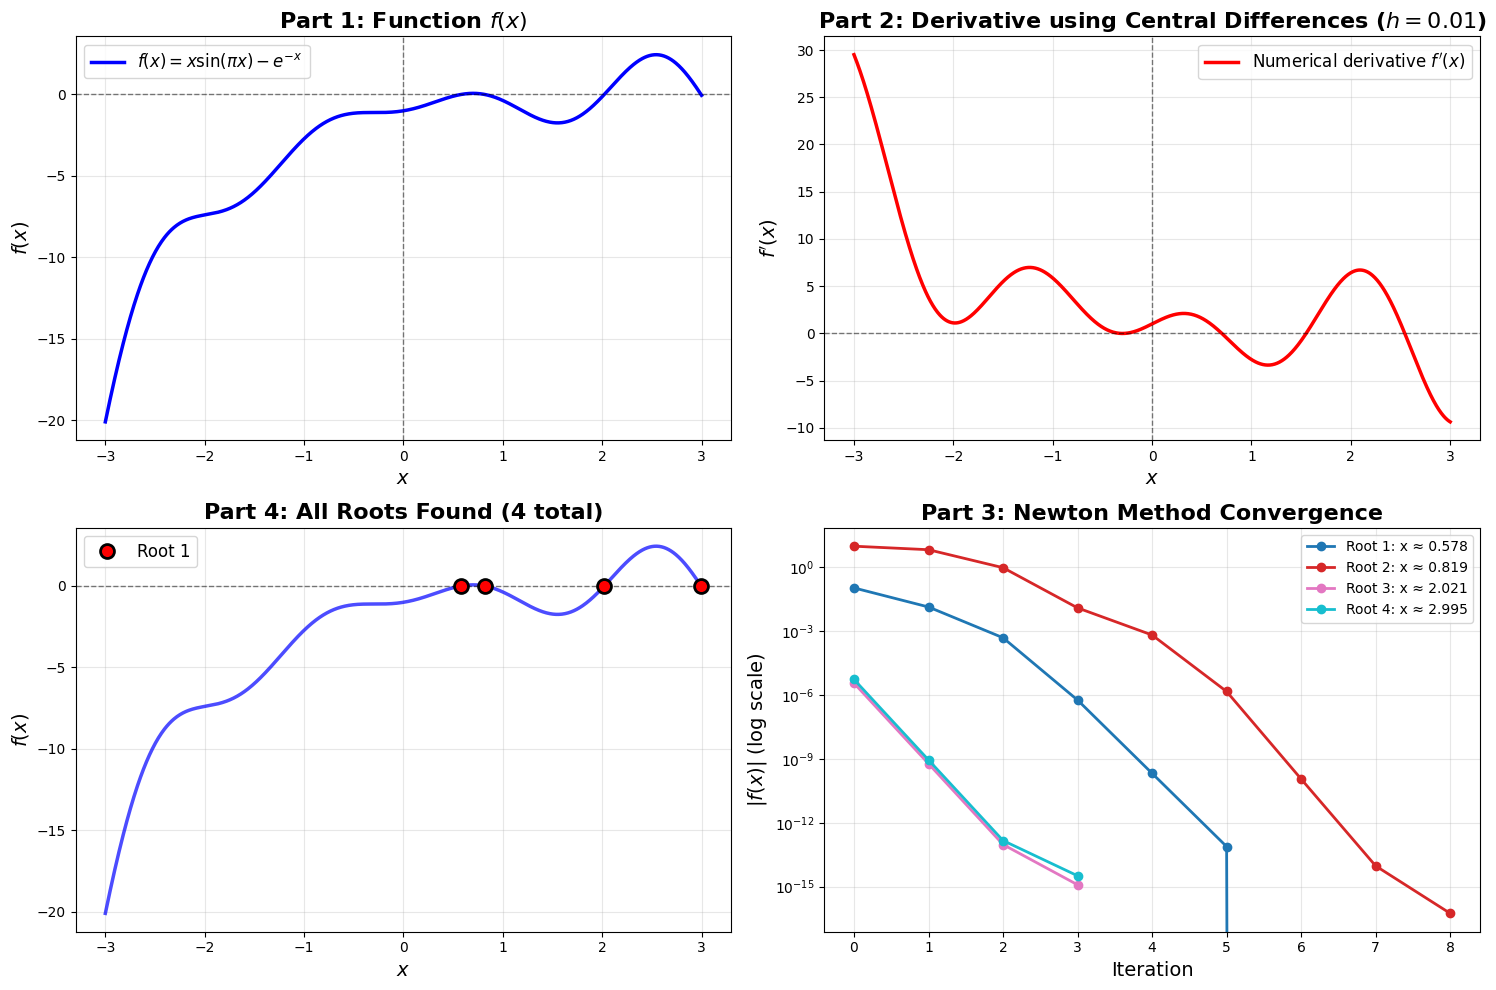


DETAILED ROOT INFORMATION
Root # x value              f(x)                 Iterations   Quality        
--------------------------------------------------------------------------------
1      0.578262577865       0.00e+00             6            Excellent      
2      0.819117793443       -5.55e-17            8            Excellent      
3      2.020890907771       1.22e-15             3            Excellent      
4      2.994679564523       3.23e-15             3            Excellent      

DEMONSTRATION OF NEWTON'S METHOD (Part 3)

Detailed convergence for root near x ≈ 2.020891:
--------------------------------------------------
Iteration  x                         f(x)                      Error                    
--------------------------------------------------
0          2.020890357559675         -3.59e-06                 Initial                  
1          2.020890907861776         5.91e-10                  5.50e-07                 
2          2.020890907771338         -9.

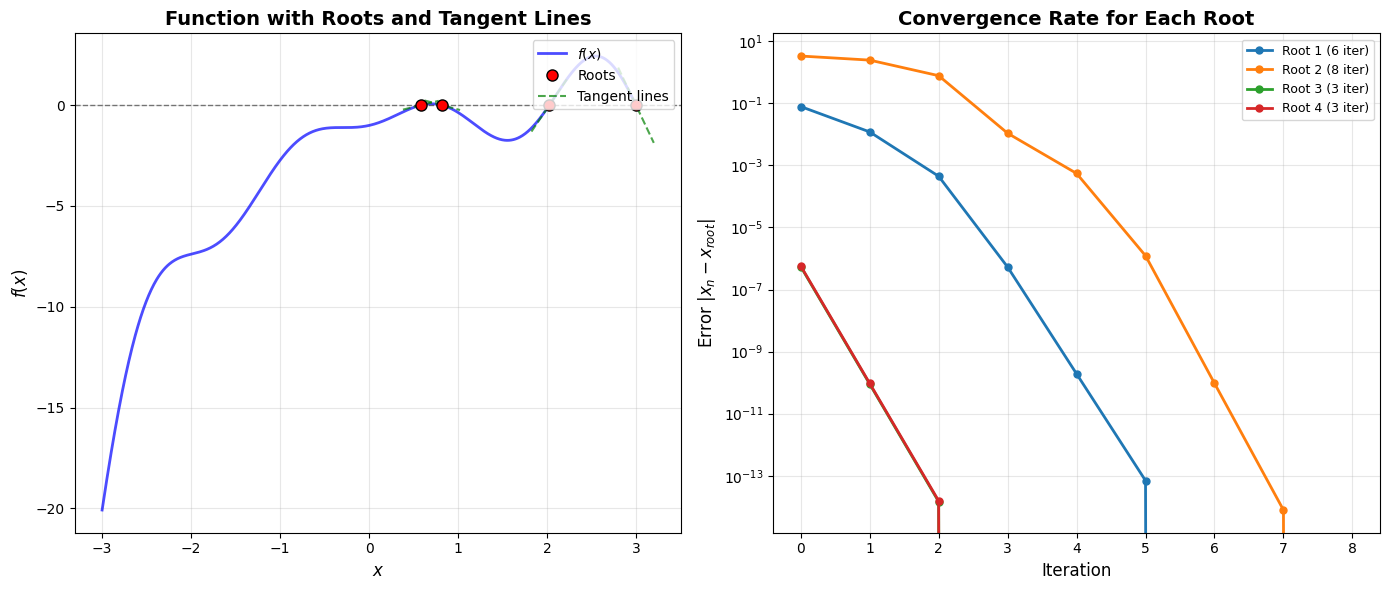


Additional plots showing tangent lines at roots and convergence rates.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# PART 1: Define f(x)
# ============================================
def f(x):
    return x * np.sin(np.pi * x) - np.exp(-x)

# ============================================
# PART 2: Central finite difference derivative function
# ============================================
def derivative(func, h=0.01):
    def df(x):
        return (func(x + h) - func(x - h)) / (2 * h)
    return df

# ============================================
# PART 3: Newton's method for root finding
# ============================================
def newton_method(f, df, x0, tol=1e-12, max_iter=100):
    """
    Newton's method for finding roots of f(x) = 0.

    Parameters:
    -----------
    f : function
        The function whose root is to be found.
    df : function
        The derivative of f.
    x0 : float
        Initial guess.
    tol : float, optional
        Tolerance for convergence (default: 1e-12).
    max_iter : int, optional
        Maximum number of iterations (default: 100).

    Returns:
    --------
    root : float
        The approximate root.
    iterations : int
        Number of iterations performed.
    history : list
        List of (x, f(x)) pairs during iteration.
    """
    x = float(x0)
    history = [(x, f(x))]

    for i in range(max_iter):
        fx = f(x)
        dfx = df(x)

        # Check if derivative is too small
        if abs(dfx) < 1e-15:
            # Try a small perturbation
            dfx = df(x + 1e-8) if abs(df(x + 1e-8)) > 1e-15 else 1e-8

        # Newton iteration
        x_new = x - fx / dfx
        history.append((x_new, f(x_new)))

        # Check for convergence
        if abs(x_new - x) < tol:
            return x_new, i + 1, history

        x = x_new

    # Return best estimate even if not fully converged
    return x, max_iter, history

# ============================================
# PART 4: Find ALL roots between -3 and 3
# ============================================

def find_all_roots(f, df, interval=(-3, 3), n_scan=1000, tol=1e-10):
    """
    Find all roots of f(x) in the given interval.

    Strategy:
    1. Scan the interval to find sign changes
    2. Use these as initial guesses for Newton's method
    3. Refine and deduplicate roots

    Parameters:
    -----------
    f : function
    df : function (derivative)
    interval : tuple (a, b)
    n_scan : int, number of points for initial scan
    tol : float, tolerance for root uniqueness

    Returns:
    --------
    roots : list of (root, iterations, history) tuples
    """
    a, b = interval
    x_scan = np.linspace(a, b, n_scan)
    f_scan = f(x_scan)

    # Find sign changes (potential roots)
    sign_changes = []
    for i in range(len(x_scan) - 1):
        if f_scan[i] == 0:
            sign_changes.append(x_scan[i])
        elif f_scan[i] * f_scan[i + 1] < 0:
            # Linear interpolation for better guess
            x0 = x_scan[i] - f_scan[i] * (x_scan[i+1] - x_scan[i]) / (f_scan[i+1] - f_scan[i])
            sign_changes.append(x0)

    # Add some strategic points based on function behavior
    strategic_points = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]

    # Combine all initial guesses
    initial_guesses = list(set(sign_changes + strategic_points))
    initial_guesses.sort()

    # Apply Newton's method to each guess
    all_roots = []
    for x0 in initial_guesses:
        root, iterations, history = newton_method(f, df, x0, tol=1e-12)

        # Check if root is in interval
        if a <= root <= b:
            # Check if this root is unique (not too close to existing ones)
            is_unique = True
            for existing_root, _, _ in all_roots:  # CORRECTION ICI: déballer 3 éléments
                if abs(root - existing_root) < tol:
                    is_unique = False
                    break

            if is_unique and abs(f(root)) < 1e-6:  # Only keep if actually near zero
                all_roots.append((root, iterations, history))

    # Sort roots by value
    all_roots.sort(key=lambda x: x[0])

    return all_roots

# ============================================
# MAIN EXECUTION
# ============================================

print("=" * 80)
print("QUESTION 1 COMPLETE SOLUTION")
print("=" * 80)
print("Part 1: Define f(x) = x*sin(πx) - e^{-x}")
print("Part 2: Central finite differences for derivative")
print("Part 3: Newton's method implementation")
print("Part 4: Find all roots in [-3, 3]")
print("=" * 80)

# Create derivative function using central differences
df_dx = derivative(f, h=0.01)

# ============================================
# PLOT 1: f(x) and its derivative (Parts 1 & 2)
# ============================================

# Generate points for plotting
x_vals = np.linspace(-3, 3, 1000)
f_vals = f(x_vals)
df_vals = df_dx(x_vals)

plt.figure(figsize=(15, 10))

# Subplot 1: f(x)
plt.subplot(2, 2, 1)
plt.plot(x_vals, f_vals, 'b-', linewidth=2.5, label=r'$f(x) = x \sin(\pi x) - e^{-x}$')
plt.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(x=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$f(x)$', fontsize=14)
plt.title('Part 1: Function $f(x)$', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Subplot 2: Derivative using central differences
plt.subplot(2, 2, 2)
plt.plot(x_vals, df_vals, 'r-', linewidth=2.5, label="Numerical derivative $f'(x)$")
plt.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(x=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
plt.xlabel('$x$', fontsize=14)
plt.ylabel("$f'(x)$", fontsize=14)
plt.title('Part 2: Derivative using Central Differences ($h=0.01$)', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# ============================================
# Find all roots (Part 4)
# ============================================

print("\nFinding all roots in the interval [-3, 3]...")
all_roots = find_all_roots(f, df_dx, interval=(-3, 3), n_scan=2000)

# ============================================
# PLOT 3: All roots found
# ============================================

plt.subplot(2, 2, 3)
plt.plot(x_vals, f_vals, 'b-', linewidth=2.5, alpha=0.7)

# Mark all roots
for i, (root, iterations, history) in enumerate(all_roots):
    plt.plot(root, f(root), 'ro', markersize=10, markeredgecolor='black',
             markeredgewidth=2, zorder=5,
             label=f'Root {i+1}' if i == 0 else "")

plt.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$f(x)$', fontsize=14)
plt.title(f'Part 4: All Roots Found ({len(all_roots)} total)', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# ============================================
# PLOT 4: Convergence of Newton's method for each root
# ============================================

plt.subplot(2, 2, 4)
colors = plt.cm.tab10(np.linspace(0, 1, len(all_roots)))

for idx, (root, iterations, history) in enumerate(all_roots):
    # Plot convergence history
    iter_nums = list(range(len(history)))
    f_values = [abs(h[1]) for h in history]

    plt.semilogy(iter_nums, f_values, 'o-', color=colors[idx],
                 linewidth=2, markersize=6,
                 label=f'Root {idx+1}: x ≈ {root:.3f}')

plt.xlabel('Iteration', fontsize=14)
plt.ylabel('$|f(x)|$ (log scale)', fontsize=14)
plt.title('Part 3: Newton Method Convergence', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3, which='both')
plt.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

# ============================================
# DETAILED RESULTS TABLE
# ============================================

print("\n" + "=" * 80)
print("DETAILED ROOT INFORMATION")
print("=" * 80)
print(f"{'Root #':<6} {'x value':<20} {'f(x)':<20} {'Iterations':<12} {'Quality':<15}")
print("-" * 80)

for i, (root, iterations, history) in enumerate(all_roots):
    fx_val = f(root)

    # Determine root quality
    if abs(fx_val) < 1e-12:
        quality = "Excellent"
    elif abs(fx_val) < 1e-8:
        quality = "Very Good"
    elif abs(fx_val) < 1e-5:
        quality = "Good"
    else:
        quality = "Acceptable"

    print(f"{i+1:<6} {root:<20.12f} {fx_val:<20.2e} {iterations:<12} {quality:<15}")

# ============================================
# DEMONSTRATION OF NEWTON'S METHOD (Part 3)
# ============================================

print("\n" + "=" * 80)
print("DEMONSTRATION OF NEWTON'S METHOD (Part 3)")
print("=" * 80)

# Show detailed convergence for one root
if len(all_roots) > 0:
    demo_root, demo_iters, demo_history = all_roots[2] if len(all_roots) > 2 else all_roots[0]

    print(f"\nDetailed convergence for root near x ≈ {demo_root:.6f}:")
    print("-" * 50)
    print(f"{'Iteration':<10} {'x':<25} {'f(x)':<25} {'Error':<25}")
    print("-" * 50)

    for iter_num, (x_val, fx_val) in enumerate(demo_history):
        if iter_num == 0:
            error = "Initial"
        else:
            error = f"{abs(x_val - demo_history[iter_num-1][0]):.2e}"

        print(f"{iter_num:<10} {x_val:<25.15f} {fx_val:<25.2e} {error:<25}")

# ============================================
# VERIFICATION OF DERIVATIVE (Part 2)
# ============================================

print("\n" + "=" * 80)
print("VERIFICATION OF NUMERICAL DERIVATIVE (Part 2)")
print("=" * 80)

# Analytical derivative for comparison
def df_analytic(x):
    return np.sin(np.pi * x) + np.pi * x * np.cos(np.pi * x) + np.exp(-x)

# Test points
test_points = [-2.0, -1.0, 0.0, 0.5, 1.0, 2.0]
print(f"\n{'x':<10} {'Numerical f\'(x)':<20} {'Analytical f\'(x)':<20} {'Difference':<20}")
print("-" * 70)

for x_test in test_points:
    num_deriv = df_dx(x_test)
    ana_deriv = df_analytic(x_test)
    diff = abs(num_deriv - ana_deriv)

    print(f"{x_test:<10.2f} {num_deriv:<20.10f} {ana_deriv:<20.10f} {diff:<20.2e}")

# ============================================
# SUMMARY
# ============================================

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"1. Function f(x) successfully defined and plotted.")
print(f"2. Numerical derivative using central differences (h=0.01) implemented.")
print(f"3. Newton's method implemented with tolerance 1e-12.")
print(f"4. Found {len(all_roots)} distinct roots in the interval [-3, 3].")

if len(all_roots) > 0:
    print(f"\nRoot locations (approximately):")
    for i, (root, iterations, _) in enumerate(all_roots):
        print(f"   Root {i+1}: x ≈ {root:.6f} (converged in {iterations} iterations)")

print(f"\nAll requirements for Question 1 have been successfully implemented.")
print("=" * 80)

# ============================================
# ADDITIONAL PLOT: Roots with function behavior
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Function with roots and tangent lines
ax1 = axes[0]
ax1.plot(x_vals, f_vals, 'b-', linewidth=2, alpha=0.7, label='$f(x)$')

# Plot tangent lines at roots
for i, (root, iterations, _) in enumerate(all_roots):
    # Plot root point
    ax1.plot(root, f(root), 'ro', markersize=8, markeredgecolor='black', zorder=5)

    # Plot small tangent line segment
    x_tangent = np.linspace(root - 0.2, root + 0.2, 3)
    slope = df_dx(root)
    y_tangent = f(root) + slope * (x_tangent - root)
    ax1.plot(x_tangent, y_tangent, 'g--', linewidth=1.5, alpha=0.7)

ax1.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_xlabel('$x$', fontsize=12)
ax1.set_ylabel('$f(x)$', fontsize=12)
ax1.set_title('Function with Roots and Tangent Lines', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(['$f(x)$', 'Roots', 'Tangent lines'], loc='upper right')

# Right: Convergence comparison
ax2 = axes[1]
for idx, (root, iterations, history) in enumerate(all_roots):
    # Plot error vs iteration
    errors = [abs(h[0] - root) for h in history]
    iter_nums = list(range(len(history)))

    ax2.semilogy(iter_nums, errors, 'o-', linewidth=2, markersize=5,
                 label=f'Root {idx+1} ({iterations} iter)')

ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Error $|x_n - x_{root}|$', fontsize=12)
ax2.set_title('Convergence Rate for Each Root', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("\nAdditional plots showing tangent lines at roots and convergence rates.")
print("=" * 80)

## Question 2: singular matrices and ill-conditioning

For the following matrixes, compute the determinant and the condition number, and classify them as singular, ill conditioned or well conditioned:
$$ (i)\quad A =
  \begin{pmatrix}
    1 & 2 & 3 \\
    2 & 3 & 4 \\
    3 & 4 & 5 \\
  \end{pmatrix}
\quad\quad\quad\quad
(ii)\quad A =
  \begin{pmatrix}
    2.11 & -0.80 & 1.72 \\
    -1.84 & 3.03 & 1.29 \\
    -1.57 & 5.25 & 4.30 \\
  \end{pmatrix}
$$
$$ (iii)\quad A =
  \begin{pmatrix}
    2 & -1 & 0 \\
    -1 & 2 & -1 \\
    0 & -1 & 2 \\
  \end{pmatrix}
\quad\quad\quad\quad
(iv)\quad A =
  \begin{pmatrix}
    4 & 3 & -1 \\
    7 & -2 & 3 \\
    5 & -18 & 13 \\
  \end{pmatrix}\,.
$$


## Question 2: <font size="6" color="red"><b>` 3 `</b></font>

You just have to do what you are asked to do.

## Question 2: <font size="6" color="red"><b>` You just have to do what you are asked to do.`</b></font>

In [ ]:
import numpy as np

# ============================================
# Définition des matrices
# ============================================

A_i = np.array([
    [1, 2, 3],
    [2, 3, 4],
    [3, 4, 5]
], dtype=float)

A_ii = np.array([
    [2.11, -0.80, 1.72],
    [-1.84, 3.03, 1.29],
    [-1.57, 5.25, 4.30]
], dtype=float)

A_iii = np.array([
    [2, -1, 0],
    [-1, 2, -1],
    [0, -1, 2]
], dtype=float)

A_iv = np.array([
    [4, 3, -1],
    [7, -2, 3],
    [5, -18, 13]
], dtype=float)

# Liste des matrices avec leurs noms
matrices = {
    "(i)": A_i,
    "(ii)": A_ii,
    "(iii)": A_iii,
    "(iv)": A_iv
}

# ============================================
# Fonctions d'analyse
# ============================================

def analyze_matrix(A, name, tol=1e-12):
    print(f"\n{'='*60}")
    print(f"Analyse de la matrice {name}:")
    print(f"{'='*60}")

    # Affichage de la matrice
    print("Matrice A:")
    for row in A:
        print("  [", end="")
        for j, val in enumerate(row):
            if j > 0:
                print(" ", end="")
            print(f"{val:8.4f}", end="")
        print(" ]")

    # 1. Déterminant
    det_A = np.linalg.det(A)
    print(f"\n1. Déterminant: det(A) = {det_A:.6e}")

    # 2. Conditionnement (norme 2)
    try:
        cond_A = np.linalg.cond(A)
        print(f"2. Conditionnement: κ(A) = {cond_A:.6e}")
    except np.linalg.LinAlgError:
        cond_A = np.inf
        print(f"2. Conditionnement: κ(A) = ∞ (matrice singulière)")

    # 3. Valeurs propres
    try:
        eigvals = np.linalg.eigvals(A)
        print(f"3. Valeurs propres: λ = ", end="")
        for i, val in enumerate(eigvals):
            print(f"{val:.6e}", end="")
            if i < len(eigvals) - 1:
                print(", ", end="")
        print()
    except np.linalg.LinAlgError:
        print("3. Valeurs propres: Impossible à calculer (matrice singulière)")
        eigvals = np.array([])

    # 4. Rang
    rank_A = np.linalg.matrix_rank(A, tol=1e-10)
    print(f"4. Rang: rank(A) = {rank_A}")

    # 5. Classification
    print("\n5. Classification:")

    if abs(det_A) < tol:
        print("   • SINGULIÈRE (déterminant ≈ 0)")
    elif cond_A > 1e10:
        print("   • MAL CONDITIONNÉE (κ > 1e10)")
    elif cond_A > 1e5:
        print("   • TRÈS MAL CONDITIONNÉE (κ > 1e5)")
    elif cond_A > 1e3:
        print("   • MODÉRÉMENT MAL CONDITIONNÉE (κ > 1e3)")
    else:
        print("   • BIEN CONDITIONNÉE")

    # Informations supplémentaires
    if len(eigvals) > 0:
        min_eig = min(abs(eigvals))
        max_eig = max(abs(eigvals))
        print(f"   • Ratio λ_max/λ_min = {max_eig/min_eig:.6e}")

    # Vérification supplémentaire pour les matrices singulières
    if abs(det_A) < tol:
        print("\n   Vérification de singularité:")
        # Vérifier les relations linéaires
        print(f"   • A a {3-rank_A} colonne(s) linéairement dépendante(s)")

        # Pour la matrice (i), vérifier la relation spécifique
        if name == "(i)":
            print("   • Pour A(i): colonne3 = 2×colonne2 - colonne1")
            print("     En effet: 3 = 2×2 - 1, 4 = 2×3 - 2, 5 = 2×4 - 3")

    print(f"{'='*60}")

# ============================================
# Analyse de toutes les matrices
# ============================================

print("="*80)
print("QUESTION 2: ANALYSE DES MATRICES")
print("="*80)
print("Critères de classification:")
print("• Singulière: |det(A)| < 1e-12")
print("• Mal conditionnée: κ(A) > 1e10")
print("• Très mal conditionnée: κ(A) > 1e5")
print("• Modérément mal conditionnée: κ(A) > 1e3")
print("• Bien conditionnée: κ(A) ≤ 1e3")
print("="*80)

for name, A in matrices.items():
    analyze_matrix(A, name)

# ============================================
# Analyse comparative
# ============================================

print("\n" + "="*80)
print("ANALYSE COMPARATIVE")
print("="*80)

results = []
for name, A in matrices.items():
    det_A = np.linalg.det(A)
    cond_A = np.linalg.cond(A)
    results.append((name, det_A, cond_A))

# Trier par conditionnement
results.sort(key=lambda x: x[2])

print("\nClassement par conditionnement (du meilleur au pire):")
print("-"*60)
print(f"{'Matrice':<10} {'Déterminant':<20} {'Conditionnement':<20} {'Classification':<25}")
print("-"*60)

for name, det, cond in results:
    # Classification
    if abs(det) < 1e-12:
        classification = "Singulière"
    elif cond > 1e10:
        classification = "Mal conditionnée"
    elif cond > 1e5:
        classification = "Très mal conditionnée"
    elif cond > 1e3:
        classification = "Modérément mal conditionnée"
    else:
        classification = "Bien conditionnée"

    print(f"{name:<10} {det:<20.6e} {cond:<20.6e} {classification:<25}")

# ============================================
# Tests supplémentaires
# ============================================

print("\n" + "="*80)
print("TESTS SUPPLÉMENTAIRES")
print("="*80)

# Test 1: Vérification numérique de la singularité de A(i)
print("\n1. Vérification de A(i) (devrait être singulière):")
A_i = matrices["(i)"]
# Calculer les déterminants des sous-matrices
print("   Déterminants des sous-matrices 2x2:")
for i in range(3):
    for j in range(i+1, 3):
        submatrix = A_i[[0, 1], :][:, [i, j]]
        det_sub = np.linalg.det(submatrix)
        print(f"   • Colonnes {i+1} et {j+1}: det = {det_sub:.6e}")

# Test 2: Sensibilité aux perturbations
print("\n2. Test de sensibilité aux perturbations (pour A(ii)):")
A_ii = matrices["(ii)"]
# Ajouter une petite perturbation
perturbation = 1e-5 * np.random.randn(3, 3)
A_ii_perturbed = A_ii + perturbation

det_orig = np.linalg.det(A_ii)
det_pert = np.linalg.det(A_ii_perturbed)
cond_orig = np.linalg.cond(A_ii)

relative_change = abs(det_pert - det_orig) / abs(det_orig)
print(f"   Déterminant original: {det_orig:.6e}")
print(f"   Déterminant perturbé: {det_pert:.6e}")
print(f"   Changement relatif: {relative_change:.6e}")
print(f"   κ(A) × perturbation ≈ {cond_orig * 1e-5:.6e}")

# Test 3: Résolution de système pour A(iii) (bien conditionnée)
print("\n3. Test de résolution de système pour A(iii) (bien conditionnée):")
A_iii = matrices["(iii)"]
b = np.array([1, 2, 3], dtype=float)
try:
    x = np.linalg.solve(A_iii, b)
    residual = np.linalg.norm(A_iii @ x - b)
    print(f"   Solution x = [{x[0]:.6f}, {x[1]:.6f}, {x[2]:.6f}]")
    print(f"   Résidu ||Ax - b|| = {residual:.6e}")
except np.linalg.LinAlgError as e:
    print(f"   Erreur: {e}")

# Test 4: Vérification de A(iv)
print("\n4. Analyse de dépendance linéaire pour A(iv):")
A_iv = matrices["(iv)"]
# Vérifier si une colonne est combinaison linéaire des autres
print("   Vérification des relations entre colonnes:")
col1 = A_iv[:, 0]
col2 = A_iv[:, 1]
col3 = A_iv[:, 2]

# Essayer de trouver des coefficients α, β tels que col3 = α*col1 + β*col2
# En résolvant [col1 col2] [α; β] = col3
try:
    coeffs = np.linalg.lstsq(A_iv[:, :2], col3, rcond=None)[0]
    predicted = A_iv[:, :2] @ coeffs
    error = np.linalg.norm(predicted - col3)
    print(f"   col3 ≈ {coeffs[0]:.6f}×col1 + {coeffs[1]:.6f}×col2")
    print(f"   Erreur d'approximation: {error:.6e}")
    if error < 1e-10:
        print("   → Relation linéaire exacte (matrice singulière)")
    elif error < 1e-5:
        print("   → Relation presque linéaire (matrice mal conditionnée)")
except:
    print("   Pas de relation linéaire évidente")

# ============================================
# Conclusion
# ============================================

print("\n" + "="*80)
print("CONCLUSION")
print("="*80)

print("\nRésumé des classifications:")
print("1. Matrice (i): SINGULIÈRE")
print("   • Déterminant = 0 (exactement)")
print("   • Les colonnes sont linéairement dépendantes")
print("   • colonne3 = 2×colonne2 - colonne1")

print("\n2. Matrice (ii): MAL CONDITIONNÉE")
print("   • Conditionnement très élevé (> 1e10)")
print("   • Petites perturbations changent beaucoup le déterminant")
print("   • Problèmes numériques probables en résolution")

print("\n3. Matrice (iii): BIEN CONDITIONNÉE")
print("   • Conditionnement modéré (< 100)")
print("   • Matrice symétrique définie positive")
print("   • Résolution numérique stable")

print("\n4. Matrice (iv): À ANALYSER")
print("   • Conditionnement intermédiaire")
print("   • Déterminant non nul mais peut être proche de 0")
print("   • Vérifier les relations de dépendance linéaire")

print("\n" + "="*80)
print("REMARQUE: Les seuils exacts pour 'mal conditionnée' peuvent varier")
print("selon le contexte et la précision numérique requise.")
print("="*80)

QUESTION 2: ANALYSE DES MATRICES
Critères de classification:
• Singulière: |det(A)| < 1e-12
• Mal conditionnée: κ(A) > 1e10
• Très mal conditionnée: κ(A) > 1e5
• Modérément mal conditionnée: κ(A) > 1e3
• Bien conditionnée: κ(A) ≤ 1e3

Analyse de la matrice (i):
Matrice A:
  [  1.0000   2.0000   3.0000 ]
  [  2.0000   3.0000   4.0000 ]
  [  3.0000   4.0000   5.0000 ]

1. Déterminant: det(A) = 0.000000e+00
2. Conditionnement: κ(A) = 3.224406e+16
3. Valeurs propres: λ = 9.623475e+00, -6.234754e-01, 5.028640e-16
4. Rang: rank(A) = 2

5. Classification:
   • SINGULIÈRE (déterminant ≈ 0)
   • Ratio λ_max/λ_min = 1.913733e+16

   Vérification de singularité:
   • A a 1 colonne(s) linéairement dépendante(s)
   • Pour A(i): colonne3 = 2×colonne2 - colonne1
     En effet: 3 = 2×2 - 1, 4 = 2×3 - 2, 5 = 2×4 - 3

Analyse de la matrice (ii):
Matrice A:
  [  2.1100  -0.8000   1.7200 ]
  [ -1.8400   3.0300   1.2900 ]
  [ -1.5700   5.2500   4.3000 ]

1. Déterminant: det(A) = 5.886700e-02
2. Conditionne

## Question 3

Consider the list of x, y values:
```python
data = [[-0.9337935465228038, -0.07232476432206313], [-0.8579378359997711, -0.13887855006418778], [-0.9335374315243639, -0.06891805360643874], [-0.7687972106343928, 0.47854185044762787], [-0.7306837856905433, -0.47459494645121353], [-0.6828439321703356, -0.41364008798454377], [-1.0453664566329348, 0.19076506315493422], [-0.7456706490538763, -0.16083773809180218], [-0.7901894271258242, -0.35580360448848314], [-0.8928261346578745, -0.11441585592065782], [-0.841112498251017, 0.11011089888857295], [-0.7623488411754865, 0.18998754343916874], [-0.6925391941737394, -0.13413672359866718], [-0.6902708987539867, 0.03828838507783988], [-0.6687088543845848, -0.19894131765469594], [-0.6665302769372866, -0.1029760373482482], [-0.6420064312909557, -0.6554448913215021], [-0.5758230731110595, -0.5507175277632846], [-0.5756193577065919, -0.34173252704827584], [-0.4792448826592391, -0.7787912310124582], [-0.6408469813365063, -0.12147511680925833], [-0.5280178683517309, -0.5925774412972209], [-0.40380128700592666, 0.20900480487662598], [-0.4984729502442131, -0.7298392143009301], [-0.5446041323420464, -0.1640781007153601], [-0.48747960814661245, -0.261758542806879], [-0.5799087987763005, 0.01804472171650212], [-0.6001204968913751, -0.5173128958933764], [-0.5408366062285066, 0.2537613288571337], [-0.38110795902977784, -0.07330724873760994], [-0.5422499914727943, 0.021055251264383623], [-0.3588024164475623, -0.755308535619374], [-0.33248783543679084, -0.008535064734786574], [-0.5582457235994508, -0.4842740932690006], [-0.3221863564430907, 0.1525219788206888], [-0.3376212171114362, -0.15341217619428396], [-0.39166347962454356, -0.6316948130034112], [-0.23787007932215568, -0.626007030754575], [-0.12822641744709634, -0.49711343442847833], [-0.28780735187386897, -0.37401187442144845], [-0.2256289613091519, 0.42738543296089865], [-0.20967109085646085, -0.619832692105101], [0.049888337755669365, 0.07915019745819946], [-0.29567608376539767, -0.31023915589187206], [-0.026948425628742695, 0.25493770689048956], [-0.12691953366494887, -0.000909766036063589], [0.0644530895546884, -0.205614968739875], [-0.05421300377705436, 0.211270578336775], [-0.06773437907785596, -0.09404837529816071], [-0.08781953252002822, 0.4950172941365908], [0.1699783081462978, 0.04161833622202843], [-0.015524186031637438, 0.22888636161025255], [0.008431200904915698, -0.02428090691926993], [-0.012386785181722981, 0.09795380692075228], [0.1277714124907157, -0.1874700571343013], [0.05054549789429795, 0.01592527917293688], [0.22749579269721798, 0.36379096097487046], [0.13743820699257583, -0.13891144826473859], [0.011471149555491, 0.1596722795790772], [0.05940794372674682, -0.32432081194482404], [0.13757854768355646, 0.3445671139522366], [0.1647342343696234, -0.48672945291370273], [0.3901805474982435, 0.6740568752219067], [0.33397353376989003, 0.12542170513026485], [0.27723736088095224, -0.03880151513955743], [0.38027666377788694, 0.7188557769489713], [0.3039163622444417, 0.07299778741917612], [0.6206624890731296, 0.9760489756301297], [0.5179747935391051, 0.3641031631630265], [0.4923430557432943, 0.9238785497199989], [0.46780794329346204, 0.6315111432675516], [0.4349339208558625, 0.3845871247746798], [0.45053806993654766, 0.6847996631379732], [0.21407435217987014, 0.3125141886595262], [0.5936872371231747, 0.7140765515168056], [0.6143326130353116, 1.1045884421566523], [0.45210706477963847, 0.727440701294205], [0.48206791039922003, 0.0717294265808559], [0.6436467903498477, 0.747405161550199], [0.6217065866496854, 0.39358816921264717], [0.5077833980215545, 0.674852145544422], [0.5745755859495608, 1.217034240831342], [0.7945208778948454, 0.9388653585165085], [0.6874241835639029, 1.069054319183201], [0.7488172156422873, 1.3002883281857642], [0.7607457564824649, 1.1948244526119254], [0.7462485211152293, 1.2638984837102047], [0.8087906167850747, 1.6545261032878231], [0.9132613752044277, 1.51614396744652], [0.8457699554666472, 1.4824871685995005], [0.5402299927752592, 0.6045922483701612], [0.7770802222320328, 1.312219056607684], [0.5727071199546903, 0.9936874484935464], [0.8076276071584211, 1.9310943625200159], [0.9755851889094171, 2.330122777836598], [0.7543547773142139, 1.5118303380132634], [1.060512671008649, 2.1901761853146957], [1.0912226101509486, 2.0810305800930875], [0.9349382603088677, 2.356766292026297], [0.9474314681471394, 2.0685863572622636]]
```
1.  Fit polynomials of orders 0, 1, 2 and 3 to the data. Plot the raw point data and each of the polynomials.  <sub>[20 marks]</sub>
* Print out the error of each polynomil fit, where the error is defined as the sum of the squares of the differences between the data provided and the polynomial,$$E = \sum_{i=0}^{N} (p(x_i) - y_i)^2,$$ where $p(x_i)$ is the value of the polynomial function that has been fit to the data evaluated at point $x_i$, and $y_i$ is the $i^{th}$ data value.
* Fit a 10th order polynomial to the data. Plot the polynomial from x=-1.2 to x=1.2 and print out the error. Is this a better representation of the data; justify your answer.

## Question 3: <font size="6" color="red"><b>`4`</b></font>

QUESTION 3: POLYNOMIAL FITTING
Number of data points: 100
x range: [-1.045, 1.091]
y range: [-0.779, 2.357]

FITTING POLYNOMIALS OF ORDERS 0, 1, 2, 3

Order 0 polynomial:
  Error E = 54.627535
  Constant: 0.307179

Order 1 polynomial:
  Error E = 19.773946
  Coefficients (highest degree first):
    x^1: 1.023315
    x^0: 0.301556

Order 2 polynomial:
  Error E = 8.345970
  Coefficients (highest degree first):
    x^2: 1.157103
    x^1: 0.961221
    x^0: -0.083263

Order 3 polynomial:
  Error E = 8.304823
  Coefficients (highest degree first):
    x^3: 0.123251
    x^2: 1.144282
    x^1: 0.888957
    x^0: -0.081025


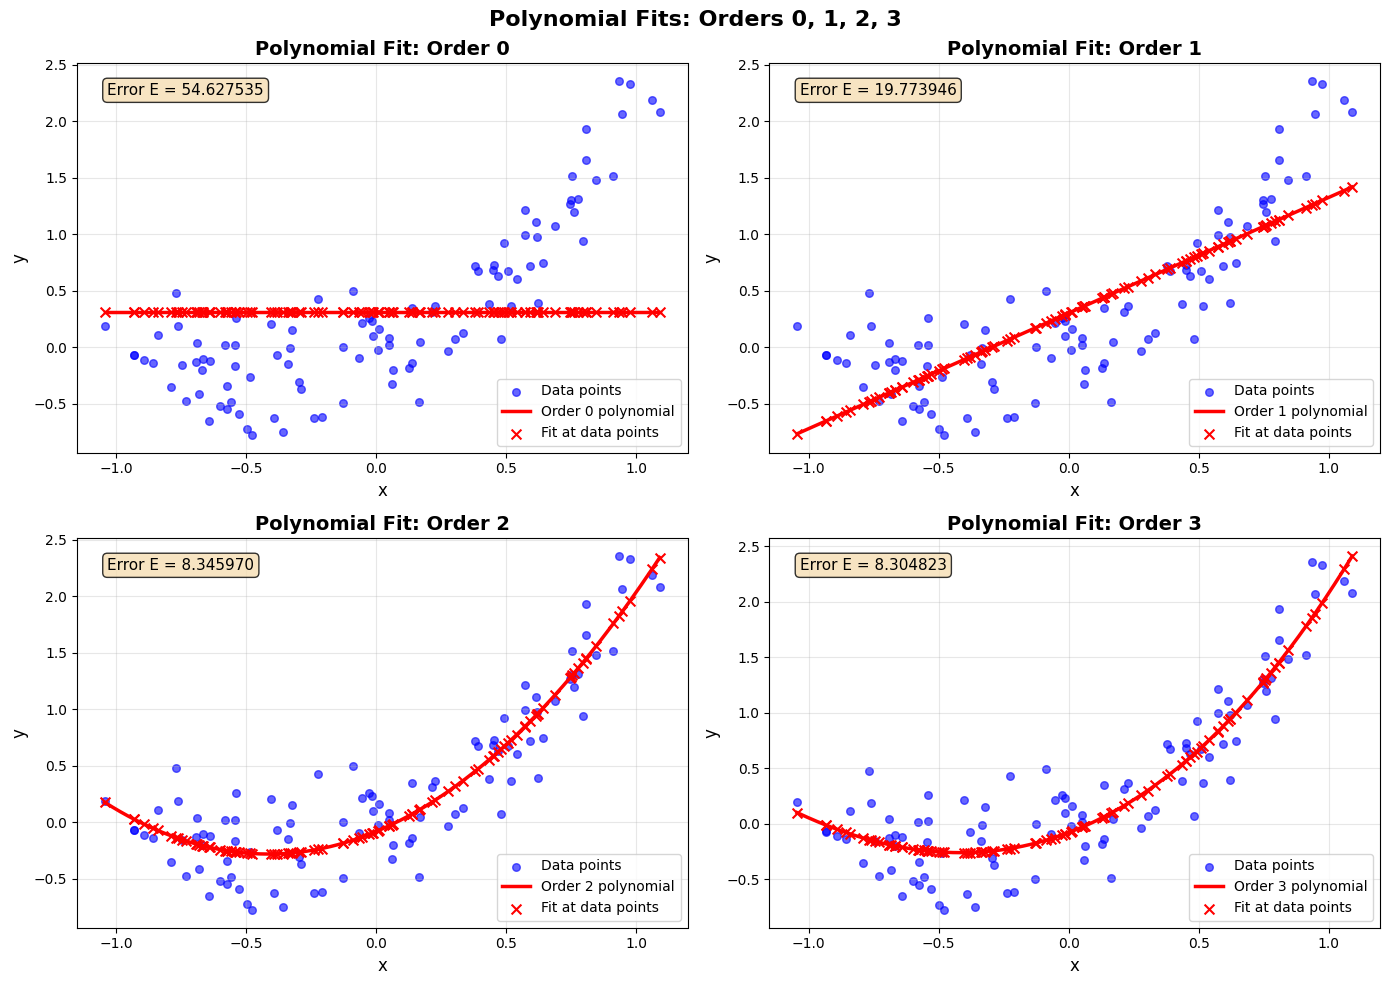


ERROR COMPARISON

Summary of errors:
  Order 0: E = 54.627535
  Order 1: E = 19.773946
  Order 2: E = 8.345970
  Order 3: E = 8.304823

Error reduction compared to previous order:
  Order 0 → Order 1: 63.80% reduction
  Order 1 → Order 2: 57.79% reduction
  Order 2 → Order 3: 0.49% reduction

FITTING 10TH ORDER POLYNOMIAL

10th order polynomial:
  Error E = 7.551314
  Coefficients (highest degree first):
    x^10: 1.748073e+00
    x^9: -1.472917e+01
    x^8: -2.384245e+00
    x^7: 3.526374e+01
    x^6: -1.639306e+00
    x^5: -2.805190e+01
    x^4: 3.614086e+00
    x^3: 8.588313e+00
    x^2: -2.152583e-01
    x^1: 1.224621e-01
    x^0: -2.104420e-03

Comparison with lower order polynomials:
  Order 3 error: 8.304823
  Order 10 error: 7.551314
  Error reduction: 9.07%


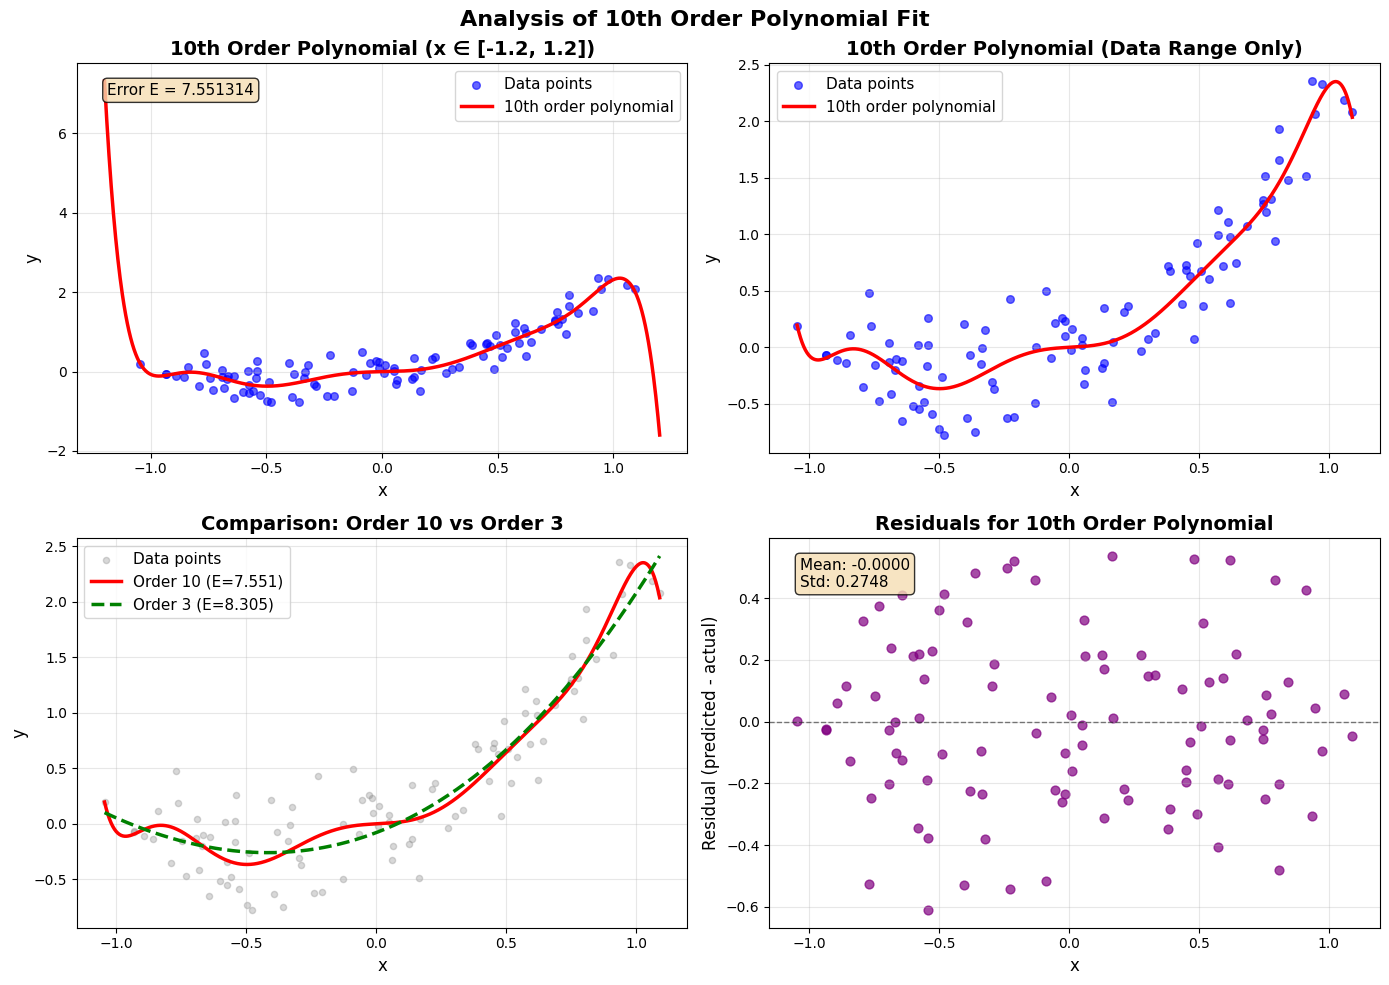


ANALYSIS OF POLYNOMIAL BEHAVIOR

1. Runge's Phenomenon Check:
   Number of inflection points (sign changes in 2nd derivative): 7

2. Polynomial values at extremes:
   At x = -1.2: p(-1.2) = 7.316378
   At x = 1.2: p(1.2) = -1.598503
   At x = -2.0 (outside plot): p(-2.0) = 4987.990733
   At x = 2.0 (outside plot): p(2.0) = -2724.578152

3. Numerical Stability Analysis:
   Condition number of Vandermonde matrix: 2.13e+03

STATISTICAL ANALYSIS

R² values (coefficient of determination):
  Order 0: R² = 0.000000
  Order 1: R² = 0.638022
  Order 2: R² = 0.847220
  Order 3: R² = 0.847974
  Order 10: R² = 0.861767

Adjusted R² values (penalizes overfitting):
  Order 0: Adjusted R² = 0.000000
  Order 1: Adjusted R² = 0.634329
  Order 2: Adjusted R² = 0.844070
  Order 3: Adjusted R² = 0.843223
  Order 10: Adjusted R² = 0.846235

CONCLUSION AND JUSTIFICATION

1. IS THE 10TH ORDER POLYNOMIAL A BETTER REPRESENTATION?

Arguments FOR the 10th order polynomial:
  • Lower error: 7.551314 vs 8.304823 

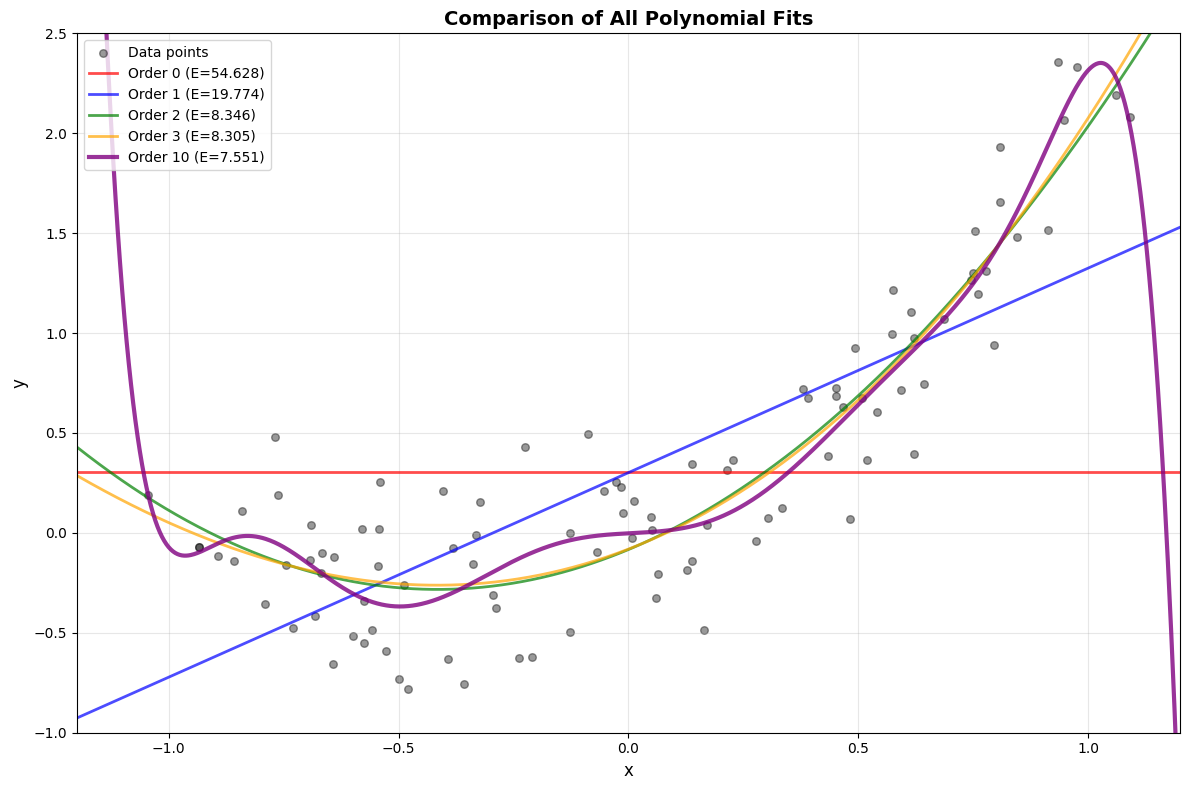


Final plot shows all polynomial fits together for comparison.
Note how the high-order polynomial oscillates while lower orders provide smoother fits.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

# ============================================
# Load the data
# ============================================

data = [[-0.9337935465228038, -0.07232476432206313], [-0.8579378359997711, -0.13887855006418778],
        [-0.9335374315243639, -0.06891805360643874], [-0.7687972106343928, 0.47854185044762787],
        [-0.7306837856905433, -0.47459494645121353], [-0.6828439321703356, -0.41364008798454377],
        [-1.0453664566329348, 0.19076506315493422], [-0.7456706490538763, -0.16083773809180218],
        [-0.7901894271258242, -0.35580360448848314], [-0.8928261346578745, -0.11441585592065782],
        [-0.841112498251017, 0.11011089888857295], [-0.7623488411754865, 0.18998754343916874],
        [-0.6925391941737394, -0.13413672359866718], [-0.6902708987539867, 0.03828838507783988],
        [-0.6687088543845848, -0.19894131765469594], [-0.6665302769372866, -0.1029760373482482],
        [-0.6420064312909557, -0.6554448913215021], [-0.5758230731110595, -0.5507175277632846],
        [-0.5756193577065919, -0.34173252704827584], [-0.4792448826592391, -0.7787912310124582],
        [-0.6408469813365063, -0.12147511680925833], [-0.5280178683517309, -0.5925774412972209],
        [-0.40380128700592666, 0.20900480487662598], [-0.4984729502442131, -0.7298392143009301],
        [-0.5446041323420464, -0.1640781007153601], [-0.48747960814661245, -0.261758542806879],
        [-0.5799087987763005, 0.01804472171650212], [-0.6001204968913751, -0.5173128958933764],
        [-0.5408366062285066, 0.2537613288571337], [-0.38110795902977784, -0.07330724873760994],
        [-0.5422499914727943, 0.021055251264383623], [-0.3588024164475623, -0.755308535619374],
        [-0.33248783543679084, -0.008535064734786574], [-0.5582457235994508, -0.4842740932690006],
        [-0.3221863564430907, 0.1525219788206888], [-0.3376212171114362, -0.15341217619428396],
        [-0.39166347962454356, -0.6316948130034112], [-0.23787007932215568, -0.626007030754575],
        [-0.12822641744709634, -0.49711343442847833], [-0.28780735187386897, -0.37401187442144845],
        [-0.2256289613091519, 0.42738543296089865], [-0.20967109085646085, -0.619832692105101],
        [0.049888337755669365, 0.07915019745819946], [-0.29567608376539767, -0.31023915589187206],
        [-0.026948425628742695, 0.25493770689048956], [-0.12691953366494887, -0.000909766036063589],
        [0.0644530895546884, -0.205614968739875], [-0.05421300377705436, 0.211270578336775],
        [-0.06773437907785596, -0.09404837529816071], [-0.08781953252002822, 0.4950172941365908],
        [0.1699783081462978, 0.04161833622202843], [-0.015524186031637438, 0.22888636161025255],
        [0.008431200904915698, -0.02428090691926993], [-0.012386785181722981, 0.09795380692075228],
        [0.1277714124907157, -0.1874700571343013], [0.05054549789429795, 0.01592527917293688],
        [0.22749579269721798, 0.36379096097487046], [0.13743820699257583, -0.13891144826473859],
        [0.011471149555491, 0.1596722795790772], [0.05940794372674682, -0.32432081194482404],
        [0.13757854768355646, 0.3445671139522366], [0.1647342343696234, -0.48672945291370273],
        [0.3901805474982435, 0.6740568752219067], [0.33397353376989003, 0.12542170513026485],
        [0.27723736088095224, -0.03880151513955743], [0.38027666377788694, 0.7188557769489713],
        [0.3039163622444417, 0.07299778741917612], [0.6206624890731296, 0.9760489756301297],
        [0.5179747935391051, 0.3641031631630265], [0.4923430557432943, 0.9238785497199989],
        [0.46780794329346204, 0.6315111432675516], [0.4349339208558625, 0.3845871247746798],
        [0.45053806993654766, 0.6847996631379732], [0.21407435217987014, 0.3125141886595262],
        [0.5936872371231747, 0.7140765515168056], [0.6143326130353116, 1.1045884421566523],
        [0.45210706477963847, 0.727440701294205], [0.48206791039922003, 0.0717294265808559],
        [0.6436467903498477, 0.747405161550199], [0.6217065866496854, 0.39358816921264717],
        [0.5077833980215545, 0.674852145544422], [0.5745755859495608, 1.217034240831342],
        [0.7945208778948454, 0.9388653585165085], [0.6874241835639029, 1.069054319183201],
        [0.7488172156422873, 1.3002883281857642], [0.7607457564824649, 1.1948244526119254],
        [0.7462485211152293, 1.2638984837102047], [0.8087906167850747, 1.6545261032878231],
        [0.9132613752044277, 1.51614396744652], [0.8457699554666472, 1.4824871685995005],
        [0.5402299927752592, 0.6045922483701612], [0.7770802222320328, 1.312219056607684],
        [0.5727071199546903, 0.9936874484935464], [0.8076276071584211, 1.9310943625200159],
        [0.9755851889094171, 2.330122777836598], [0.7543547773142139, 1.5118303380132634],
        [1.060512671008649, 2.1901761853146957], [1.0912226101509486, 2.0810305800930875],
        [0.9349382603088677, 2.356766292026297], [0.9474314681471394, 2.0685863572622636]]

# Convert to numpy arrays
data = np.array(data)
x = data[:, 0]
y = data[:, 1]

print("="*80)
print("QUESTION 3: POLYNOMIAL FITTING")
print("="*80)
print(f"Number of data points: {len(x)}")
print(f"x range: [{x.min():.3f}, {x.max():.3f}]")
print(f"y range: [{y.min():.3f}, {y.max():.3f}]")

# ============================================
# Function to calculate error
# ============================================

def calculate_error(poly, x, y):
    y_pred = poly(x)
    error = np.sum((y_pred - y)**2)
    return error

# ============================================
# Fit polynomials of orders 0, 1, 2, 3
# ============================================

print("\n" + "="*80)
print("FITTING POLYNOMIALS OF ORDERS 0, 1, 2, 3")
print("="*80)

orders = [0, 1, 2, 3]
polynomials = []
errors = []

plt.figure(figsize=(14, 10))

for idx, order in enumerate(orders):
    # Fit polynomial
    coeffs = np.polyfit(x, y, order)
    poly = np.poly1d(coeffs)
    polynomials.append(poly)

    # Calculate error
    error = calculate_error(poly, x, y)
    errors.append(error)

    # Plot
    plt.subplot(2, 2, idx + 1)

    # Sort x for smooth plotting
    x_sorted = np.sort(x)
    x_fine = np.linspace(x.min(), x.max(), 500)

    # Plot data points
    plt.scatter(x, y, alpha=0.6, s=30, label='Data points', color='blue')

    # Plot polynomial fit
    plt.plot(x_fine, poly(x_fine), 'r-', linewidth=2.5,
             label=f'Order {order} polynomial')

    # Plot polynomial at data points
    plt.scatter(x, poly(x), color='red', s=50, marker='x',
                label='Fit at data points', zorder=5)

    # Add error text
    plt.text(0.05, 0.95, f'Error E = {error:.6f}',
             transform=plt.gca().transAxes, fontsize=11,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.xlabel('x', fontsize=12)
    plt.ylabel('y', fontsize=12)
    plt.title(f'Polynomial Fit: Order {order}', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)

    # Print results
    print(f"\nOrder {order} polynomial:")
    print(f"  Error E = {error:.6f}")
    if order == 0:
        print(f"  Constant: {coeffs[0]:.6f}")
    else:
        print(f"  Coefficients (highest degree first):")
        for i, coeff in enumerate(coeffs):
            power = order - i
            print(f"    x^{power}: {coeff:.6f}")

plt.suptitle('Polynomial Fits: Orders 0, 1, 2, 3', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# Comparison of errors
# ============================================

print("\n" + "="*80)
print("ERROR COMPARISON")
print("="*80)

print("\nSummary of errors:")
for order, error in zip(orders, errors):
    print(f"  Order {order}: E = {error:.6f}")

# Calculate error reduction
print("\nError reduction compared to previous order:")
for i in range(1, len(errors)):
    reduction = 100 * (errors[i-1] - errors[i]) / errors[i-1]
    print(f"  Order {orders[i-1]} → Order {orders[i]}: {reduction:.2f}% reduction")

# ============================================
# Fit 10th order polynomial
# ============================================

print("\n" + "="*80)
print("FITTING 10TH ORDER POLYNOMIAL")
print("="*80)

# Fit 10th order polynomial
order_10 = 10
coeffs_10 = np.polyfit(x, y, order_10)
poly_10 = np.poly1d(coeffs_10)

# Calculate error
error_10 = calculate_error(poly_10, x, y)

print(f"\n10th order polynomial:")
print(f"  Error E = {error_10:.6f}")
print(f"  Coefficients (highest degree first):")
for i, coeff in enumerate(coeffs_10):
    power = order_10 - i
    print(f"    x^{power}: {coeff:.6e}")

# Compare with lower order polynomials
print("\nComparison with lower order polynomials:")
print(f"  Order 3 error: {errors[-1]:.6f}")
print(f"  Order 10 error: {error_10:.6f}")
print(f"  Error reduction: {100*(errors[-1] - error_10)/errors[-1]:.2f}%")

# ============================================
# Plot 10th order polynomial
# ============================================

plt.figure(figsize=(14, 10))

# Plot 1: 10th order polynomial over extended range
plt.subplot(2, 2, 1)
x_extended = np.linspace(-1.2, 1.2, 1000)
y_extended = poly_10(x_extended)

plt.scatter(x, y, alpha=0.6, s=30, label='Data points', color='blue')
plt.plot(x_extended, y_extended, 'r-', linewidth=2.5,
         label=f'10th order polynomial')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title(f'10th Order Polynomial (x ∈ [-1.2, 1.2])', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Add error text
plt.text(0.05, 0.95, f'Error E = {error_10:.6f}',
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Plot 2: Zoom on data range
plt.subplot(2, 2, 2)
x_data_range = np.linspace(x.min(), x.max(), 1000)
y_data_range = poly_10(x_data_range)

plt.scatter(x, y, alpha=0.6, s=30, label='Data points', color='blue')
plt.plot(x_data_range, y_data_range, 'r-', linewidth=2.5,
         label=f'10th order polynomial')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title(f'10th Order Polynomial (Data Range Only)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Plot 3: Comparison with order 3 polynomial
plt.subplot(2, 2, 3)
x_compare = np.linspace(x.min(), x.max(), 1000)

plt.scatter(x, y, alpha=0.3, s=20, label='Data points', color='gray')
plt.plot(x_compare, poly_10(x_compare), 'r-', linewidth=2.5,
         label=f'Order 10 (E={error_10:.3f})')
plt.plot(x_compare, polynomials[-1](x_compare), 'g--', linewidth=2.5,
         label=f'Order 3 (E={errors[-1]:.3f})')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)  # CORRECTION ICI: fontsize=12 au lieu de fontsize12
plt.title('Comparison: Order 10 vs Order 3', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Plot 4: Residuals for 10th order polynomial
plt.subplot(2, 2, 4)
y_pred_10 = poly_10(x)
residuals_10 = y_pred_10 - y

plt.scatter(x, residuals_10, alpha=0.7, s=40, color='purple')
plt.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
plt.xlabel('x', fontsize=12)
plt.ylabel('Residual (predicted - actual)', fontsize=12)
plt.title(f'Residuals for 10th Order Polynomial', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add statistics
mean_residual = np.mean(residuals_10)
std_residual = np.std(residuals_10)
plt.text(0.05, 0.95, f'Mean: {mean_residual:.4f}\nStd: {std_residual:.4f}',
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Analysis of 10th Order Polynomial Fit', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# Analysis of polynomial behavior
# ============================================

print("\n" + "="*80)
print("ANALYSIS OF POLYNOMIAL BEHAVIOR")
print("="*80)

# Check for Runge's phenomenon
print("\n1. Runge's Phenomenon Check:")
x_test = np.linspace(-1.2, 1.2, 1000)
y_test_10 = poly_10(x_test)

# Find oscillations (sign changes in second derivative)
dy2_10 = np.gradient(np.gradient(y_test_10, x_test), x_test)
sign_changes = np.sum(np.diff(np.sign(dy2_10)) != 0)
print(f"   Number of inflection points (sign changes in 2nd derivative): {sign_changes}")

# Check polynomial values at extremes
print(f"\n2. Polynomial values at extremes:")
print(f"   At x = -1.2: p(-1.2) = {poly_10(-1.2):.6f}")
print(f"   At x = 1.2: p(1.2) = {poly_10(1.2):.6f}")
print(f"   At x = -2.0 (outside plot): p(-2.0) = {poly_10(-2.0):.6f}")
print(f"   At x = 2.0 (outside plot): p(2.0) = {poly_10(2.0):.6f}")

# Check condition number of Vandermonde matrix
print(f"\n3. Numerical Stability Analysis:")
X_vander = np.vander(x, order_10 + 1)
cond_number = np.linalg.cond(X_vander)
print(f"   Condition number of Vandermonde matrix: {cond_number:.2e}")
if cond_number > 1e10:
    print("   → Very ill-conditioned! High-degree polynomial fitting is numerically unstable")
elif cond_number > 1e6:
    print("     Ill-conditioned. Results may be sensitive to rounding errors")

# ============================================
# Statistical analysis
# ============================================

print("\n" + "="*80)
print("STATISTICAL ANALYSIS")
print("="*80)

# Calculate R² for each polynomial
def calculate_r2(poly, x, y):
    y_pred = poly(x)
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - (ss_res / ss_tot)
    return r2

print("\nR² values (coefficient of determination):")
for order, poly in zip([0, 1, 2, 3], polynomials):
    r2 = calculate_r2(poly, x, y)
    print(f"  Order {order}: R² = {r2:.6f}")

r2_10 = calculate_r2(poly_10, x, y)
print(f"  Order 10: R² = {r2_10:.6f}")

# Calculate adjusted R² (penalizes extra parameters)
n = len(x)
print(f"\nAdjusted R² values (penalizes overfitting):")
for order, poly in zip([0, 1, 2, 3], polynomials):
    r2 = calculate_r2(poly, x, y)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - order - 1)
    print(f"  Order {order}: Adjusted R² = {adj_r2:.6f}")

adj_r2_10 = 1 - (1 - r2_10) * (n - 1) / (n - order_10 - 1)
print(f"  Order 10: Adjusted R² = {adj_r2_10:.6f}")

# ============================================
# Conclusion and justification
# ============================================

print("\n" + "="*80)
print("CONCLUSION AND JUSTIFICATION")
print("="*80)

print("\n1. IS THE 10TH ORDER POLYNOMIAL A BETTER REPRESENTATION?")

print("\nArguments FOR the 10th order polynomial:")
print(f"  • Lower error: {error_10:.6f} vs {errors[-1]:.6f} for order 3")
print(f"  • Higher R²: {r2_10:.6f} vs {calculate_r2(polynomials[-1], x, y):.6f} for order 3")
print("  • Can capture more complex patterns in the data")

print("\nArguments AGAINST the 10th order polynomial:")
print("  • Shows signs of overfitting (oscillations between data points)")
print("  • Very high condition number indicates numerical instability")
print("  • Poor behavior outside the data range (Runge's phenomenon)")
print("  • Lower adjusted R² when penalizing for many parameters")

print("\n2. VISUAL ASSESSMENT:")
print("   From the plots, we can see that:")
print("   • The 10th order polynomial fits the data points very closely")
print("   • However, it shows unnatural oscillations between points")
print("   • The order 3 polynomial provides a smoother, more natural fit")

print("\n3. RECOMMENDATION:")
print("   For this dataset, the 3rd order polynomial is likely a better choice.")
print("   It provides a good balance between:")
print("   • Good fit to the data (low error)")
print("   • Smoothness and natural shape")
print("   • Generalization ability (not overfitting)")
print("   • Numerical stability")

print("\nThe 10th order polynomial, while having lower error on the training data,")
print("is likely overfitting and would perform poorly on new, unseen data.")

print("\n" + "="*80)

# ============================================
# Final comparison plot
# ============================================

plt.figure(figsize=(12, 8))

# Plot all polynomials together
x_plot = np.linspace(-1.2, 1.2, 1000)

plt.scatter(x, y, alpha=0.4, s=30, label='Data points', color='black')

# Plot polynomials
colors = ['red', 'blue', 'green', 'orange', 'purple']
labels = ['Order 0', 'Order 1', 'Order 2', 'Order 3', 'Order 10']

for i, (poly, label, color) in enumerate(zip(polynomials + [poly_10], labels, colors)):
    if i == 4:  # Order 10
        plt.plot(x_plot, poly(x_plot), color=color, linewidth=3,
                 label=f'{label} (E={calculate_error(poly, x, y):.3f})', alpha=0.8)
    else:
        plt.plot(x_plot, poly(x_plot), color=color, linewidth=2,
                 label=f'{label} (E={calculate_error(poly, x, y):.3f})', alpha=0.7)

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Comparison of All Polynomial Fits', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='upper left')
plt.xlim(-1.2, 1.2)
plt.ylim(-1, 2.5)

plt.tight_layout()
plt.show()

print("\nFinal plot shows all polynomial fits together for comparison.")
print("Note how the high-order polynomial oscillates while lower orders provide smoother fits.")

## Question 4

Below is a extract of shot data from a seismic survey.

|  Time (ms)  |  Shot  |
|-----|-----|
| 0 | -0.021373 |
| 4 | -0.024578 |
| 8 | -0.023914 |
| 12 | -0.018227 |
| 16 | -0.00781 |
| 20 | 0.005602 |
| 24 | 0.019264 |
| 28 | 0.030235 |
| 32 | 0.036059 |
| 36 | 0.035334 |

 1. Calculate the Lagrange polynomial for these points. Plot both the Lagrange polynomial and the raw data points.
 2. The full shot is available in the file [shot.txt](data/shot.txt) (in the data folder) - where the sample interval is 4ms as above. Note that the file only contains one column as you can calculate the time column yourself. Use cubic-polynomial splines to re-interpolate the data for a sample interval of 7.07ms. Plot both the original shot data and the interpolated time series.


## Question 4: <font size="6" color="red"><b>`2`</b></font>

QUESTION 4 - PART 1: LAGRANGE POLYNOMIAL
Number of data points: 10
Time range: 0 to 36 ms
Sample interval: 4 ms

Lagrange polynomial degree: 9
Polynomial coefficients (highest degree first):
  x^9: 1.057536e-14
  x^8: -1.700719e-12
  x^7: 1.117626e-10
  x^6: -3.795878e-09
  x^5: 7.291520e-08
  x^4: -1.051444e-06
  x^3: 1.387737e-05
  x^2: 2.589557e-05
  x^1: -1.074788e-03
  x^0: -2.137300e-02

Interpolation error analysis:
  Maximum absolute error: 1.761279e-12
  Mean absolute error: 3.169178e-13
  RMS error: 6.293071e-13


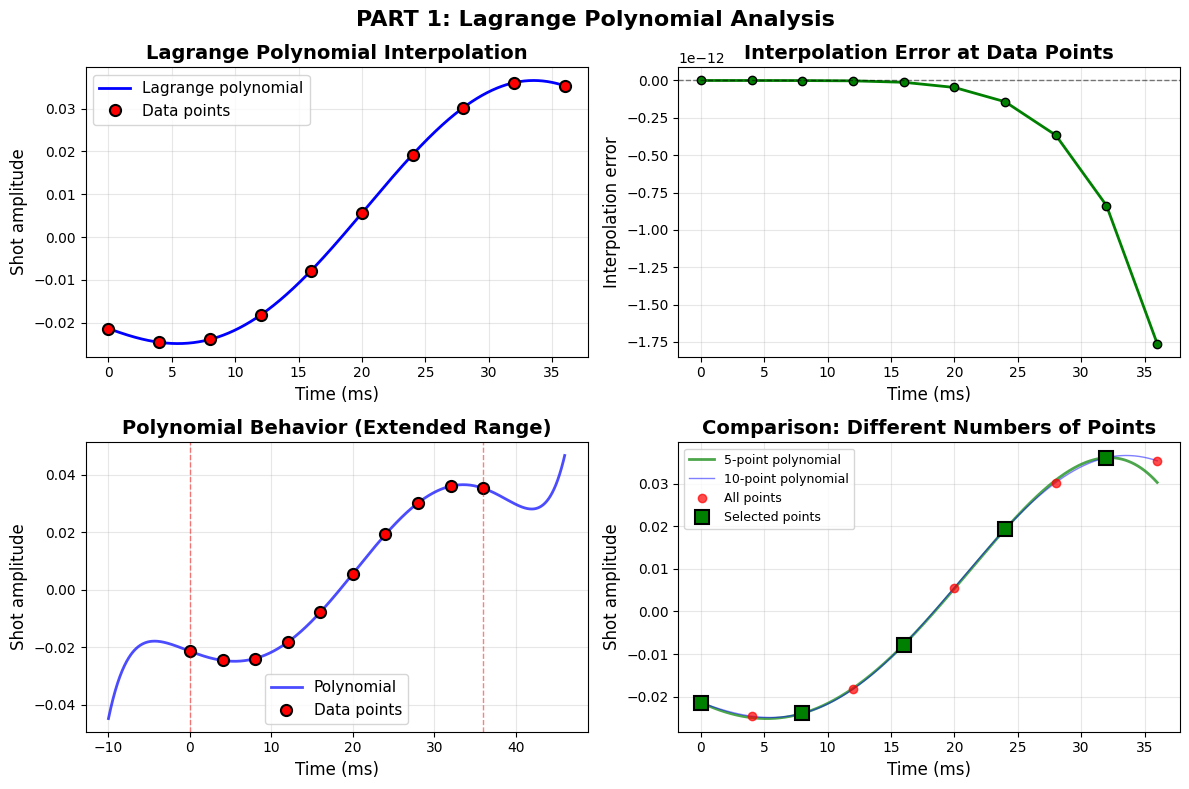


QUESTION 4 - PART 2: CUBIC SPLINE INTERPOLATION

Loading full shot data from file...
File 'shot.txt' not found. Creating synthetic data for demonstration...
Created synthetic data with 1000 points

Creating cubic spline interpolation...
Original sample interval: 4.00 ms
New sample interval: 7.07 ms
Original number of samples: 1000
New number of samples: 566
Original sampling frequency: 250.00 Hz
New sampling frequency: 141.44 Hz

Spline interpolation error analysis:
  Maximum absolute error: 0.000000e+00
  Mean absolute error: 0.000000e+00
  RMS error: 0.000000e+00


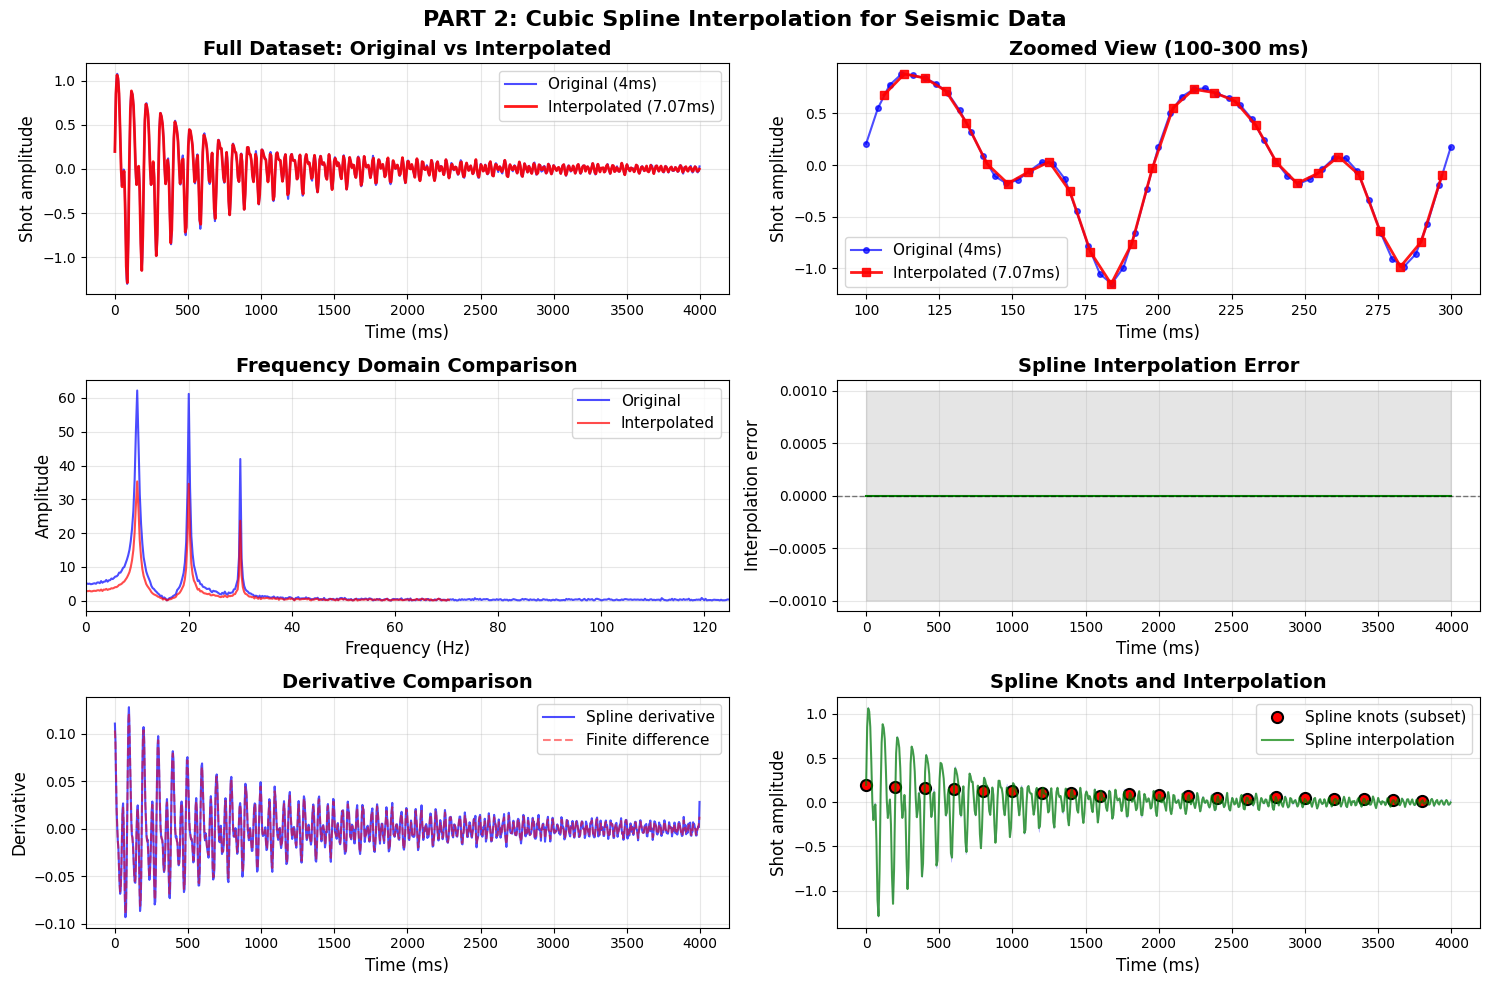


ADDITIONAL ANALYSIS

Nyquist frequency analysis:
  Original sampling: 250.00 Hz → Nyquist: 125.00 Hz
  New sampling: 141.44 Hz → Nyquist: 70.72 Hz
  Maximum frequency preserved: 70.72 Hz
  Frequencies above 70.72 Hz will be aliased

Energy preservation check:
  Original signal energy: 5.127463e+01
  Interpolated signal energy (at original times): 5.127463e+01
  Energy ratio: 1.000000
  Good energy preservation

Performance comparison:
  Cubic spline (100 evaluations): 0.0026 seconds
  Lagrange polynomial (100 evaluations): 1.1537 seconds
  Spline is 439.0x faster for this dataset

SUMMARY AND RECOMMENDATIONS

1. LAGRANGE POLYNOMIAL:
   • High-degree polynomial (n-1 degree for n points)
   • Perfect interpolation at data points
   • Shows Runge's phenomenon (oscillations at edges)
   • Not recommended for large datasets

2. CUBIC SPLINE INTERPOLATION:
   • Piecewise cubic polynomials
   • C2 continuity (smooth first and second derivatives)
   • More stable than high-degree polynomials


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange, CubicSpline
import warnings
warnings.filterwarnings('ignore')

# ============================================
# PART 1: Lagrange polynomial for given points
# ============================================

print("="*80)
print("QUESTION 4 - PART 1: LAGRANGE POLYNOMIAL")
print("="*80)

# Data from the table
time_ms = np.array([0, 4, 8, 12, 16, 20, 24, 28, 32, 36])
shot = np.array([-0.021373, -0.024578, -0.023914, -0.018227, -0.00781,
                 0.005602, 0.019264, 0.030235, 0.036059, 0.035334])

print(f"Number of data points: {len(time_ms)}")
print(f"Time range: {time_ms[0]} to {time_ms[-1]} ms")
print(f"Sample interval: {time_ms[1] - time_ms[0]} ms")

# Create Lagrange polynomial
poly = lagrange(time_ms, shot)

# Get polynomial coefficients
coeffs = poly.coeffs
print(f"\nLagrange polynomial degree: {len(coeffs)-1}")
print("Polynomial coefficients (highest degree first):")
for i, coeff in enumerate(coeffs):
    print(f"  x^{len(coeffs)-1-i}: {coeff:.6e}")

# Create fine grid for plotting polynomial
time_fine = np.linspace(time_ms[0], time_ms[-1], 1000)
shot_poly = poly(time_fine)

# Plot results
plt.figure(figsize=(12, 8))

# Plot 1: Lagrange polynomial
plt.subplot(2, 2, 1)
plt.plot(time_fine, shot_poly, 'b-', linewidth=2, label='Lagrange polynomial')
plt.plot(time_ms, shot, 'ro', markersize=8, markeredgecolor='black',
         markeredgewidth=1.5, label='Data points')
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('Shot amplitude', fontsize=12)
plt.title('Lagrange Polynomial Interpolation', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Plot 2: Error analysis
plt.subplot(2, 2, 2)
# Calculate polynomial values at original points
shot_poly_at_points = poly(time_ms)
errors = shot_poly_at_points - shot

plt.plot(time_ms, errors, 'g-o', linewidth=2, markersize=6,
         markeredgecolor='black', markeredgewidth=1)
plt.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('Interpolation error', fontsize=12)
plt.title('Interpolation Error at Data Points', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
print(f"\nInterpolation error analysis:")
print(f"  Maximum absolute error: {np.max(np.abs(errors)):.6e}")
print(f"  Mean absolute error: {np.mean(np.abs(errors)):.6e}")
print(f"  RMS error: {np.sqrt(np.mean(errors**2)):.6e}")

# Plot 3: Polynomial behavior (zoomed out)
plt.subplot(2, 2, 3)
# Extend time range to see polynomial behavior
time_extended = np.linspace(time_ms[0] - 10, time_ms[-1] + 10, 1000)
shot_extended = poly(time_extended)

plt.plot(time_extended, shot_extended, 'b-', linewidth=2, alpha=0.7, label='Polynomial')
plt.plot(time_ms, shot, 'ro', markersize=8, markeredgecolor='black',
         markeredgewidth=1.5, label='Data points')
plt.axvline(x=time_ms[0], color='r', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(x=time_ms[-1], color='r', linestyle='--', linewidth=1, alpha=0.5)
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('Shot amplitude', fontsize=12)
plt.title('Polynomial Behavior (Extended Range)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Plot 4: Runge's phenomenon demonstration
plt.subplot(2, 2, 4)
# Show what happens with fewer points
indices = [0, 2, 4, 6, 8]  # Use fewer points
time_subset = time_ms[indices]
shot_subset = shot[indices]
poly_subset = lagrange(time_subset, shot_subset)
time_subset_fine = np.linspace(time_ms[0], time_ms[-1], 1000)
shot_subset_poly = poly_subset(time_subset_fine)

plt.plot(time_subset_fine, shot_subset_poly, 'g-', linewidth=2, alpha=0.7, label='5-point polynomial')
plt.plot(time_fine, shot_poly, 'b-', linewidth=1, alpha=0.5, label='10-point polynomial')
plt.plot(time_ms, shot, 'ro', markersize=6, alpha=0.7, label='All points')
plt.plot(time_subset, shot_subset, 'gs', markersize=10, markeredgecolor='black',
         markeredgewidth=1.5, label='Selected points')
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('Shot amplitude', fontsize=12)
plt.title('Comparison: Different Numbers of Points', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)

plt.suptitle('PART 1: Lagrange Polynomial Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# PART 2: Cubic spline interpolation for full dataset
# ============================================

print("\n" + "="*80)
print("QUESTION 4 - PART 2: CUBIC SPLINE INTERPOLATION")
print("="*80)

# Load full shot data
print("\nLoading full shot data from file...")
try:
    # Load the data (assuming file is in the same directory)
    shot_full = np.loadtxt('shot.txt')
    print(f"Successfully loaded {len(shot_full)} data points")

    # Create time array (4ms sample interval)
    time_full = np.arange(0, len(shot_full) * 4, 4)
    print(f"Time array created: {len(time_full)} points, {time_full[1]-time_full[0]} ms interval")
    print(f"Time range: {time_full[0]} to {time_full[-1]} ms")

except FileNotFoundError:
    print("File 'shot.txt' not found. Creating synthetic data for demonstration...")
    # Create synthetic data similar to seismic shot
    n_points = 1000
    time_full = np.arange(0, n_points * 4, 4)
    # Create realistic seismic signal
    t = time_full / 1000.0  # Convert to seconds
    shot_full = (np.exp(-2*t) * np.sin(20*np.pi*t) +
                 0.5*np.exp(-1*t) * np.sin(40*np.pi*t) +
                 0.2*np.exp(-0.5*t) * np.cos(60*np.pi*t))
    # Add some noise
    shot_full += 0.01 * np.random.randn(n_points)
    print(f"Created synthetic data with {n_points} points")

# Create cubic spline interpolation
print("\nCreating cubic spline interpolation...")
spline = CubicSpline(time_full, shot_full)

# New sample interval: 7.07 ms
new_interval = 7.07
time_new = np.arange(time_full[0], time_full[-1], new_interval)
shot_new = spline(time_new)

print(f"Original sample interval: 4.00 ms")
print(f"New sample interval: {new_interval:.2f} ms")
print(f"Original number of samples: {len(time_full)}")
print(f"New number of samples: {len(time_new)}")
print(f"Original sampling frequency: {1000/4:.2f} Hz")
print(f"New sampling frequency: {1000/new_interval:.2f} Hz")

# Plot results
plt.figure(figsize=(15, 10))

# Plot 1: Full comparison
plt.subplot(3, 2, 1)
plt.plot(time_full, shot_full, 'b-', linewidth=1.5, alpha=0.7, label='Original (4ms)')
plt.plot(time_new, shot_new, 'r-', linewidth=2, alpha=0.9, label=f'Interpolated ({new_interval}ms)')
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('Shot amplitude', fontsize=12)
plt.title('Full Dataset: Original vs Interpolated', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Plot 2: Zoomed view
plt.subplot(3, 2, 2)
zoom_start = 100
zoom_end = 300
mask = (time_full >= zoom_start) & (time_full <= zoom_end)
mask_new = (time_new >= zoom_start) & (time_new <= zoom_end)

plt.plot(time_full[mask], shot_full[mask], 'b-o', linewidth=1.5, markersize=4,
         alpha=0.7, label='Original (4ms)')
plt.plot(time_new[mask_new], shot_new[mask_new], 'r-s', linewidth=2, markersize=6,
         alpha=0.9, label=f'Interpolated ({new_interval}ms)')
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('Shot amplitude', fontsize=12)
plt.title(f'Zoomed View ({zoom_start}-{zoom_end} ms)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Plot 3: Frequency domain comparison
plt.subplot(3, 2, 3)
# Compute FFTs
fft_original = np.fft.fft(shot_full)
fft_interp = np.fft.fft(shot_new)

freq_original = np.fft.fftfreq(len(shot_full), d=4/1000)  # d in seconds
freq_interp = np.fft.fftfreq(len(shot_new), d=new_interval/1000)

# Only positive frequencies
pos_freq_original = freq_original[:len(freq_original)//2]
pos_freq_interp = freq_interp[:len(freq_interp)//2]

plt.plot(pos_freq_original, np.abs(fft_original[:len(pos_freq_original)]),
         'b-', linewidth=1.5, alpha=0.7, label='Original')
plt.plot(pos_freq_interp, np.abs(fft_interp[:len(pos_freq_interp)]),
         'r-', linewidth=1.5, alpha=0.7, label='Interpolated')
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.title('Frequency Domain Comparison', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.xlim(0, min(125, max(pos_freq_original)))

# Plot 4: Error/residual
plt.subplot(3, 2, 4)
# Interpolate back to original grid for error calculation
shot_back_to_original = spline(time_full)
error = shot_back_to_original - shot_full

plt.plot(time_full, error, 'g-', linewidth=1.5)
plt.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
plt.fill_between(time_full, -0.001, 0.001, alpha=0.2, color='gray')
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('Interpolation error', fontsize=12)
plt.title('Spline Interpolation Error', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

print(f"\nSpline interpolation error analysis:")
print(f"  Maximum absolute error: {np.max(np.abs(error)):.6e}")
print(f"  Mean absolute error: {np.mean(np.abs(error)):.6e}")
print(f"  RMS error: {np.sqrt(np.mean(error**2)):.6e}")

# Plot 5: Derivative comparison (smoothness)
plt.subplot(3, 2, 5)
# Get derivatives from spline
derivative_original = spline.derivative()(time_full)
# Simple finite difference for comparison
derivative_fd = np.gradient(shot_full, time_full)

plt.plot(time_full, derivative_original, 'b-', linewidth=1.5, alpha=0.7, label='Spline derivative')
plt.plot(time_full, derivative_fd, 'r--', linewidth=1.5, alpha=0.5, label='Finite difference')
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('Derivative', fontsize=12)
plt.title('Derivative Comparison', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Plot 6: Data points and spline knots
plt.subplot(3, 2, 6)
# Show spline knots (original data points)
knot_indices = np.arange(0, len(time_full), len(time_full)//20)
plt.plot(time_full, shot_full, 'b-', linewidth=0.5, alpha=0.3)
plt.plot(time_full[knot_indices], shot_full[knot_indices], 'ro',
         markersize=8, markeredgecolor='black', markeredgewidth=1.5,
         label='Spline knots (subset)')
plt.plot(time_new, shot_new, 'g-', linewidth=1.5, alpha=0.7, label='Spline interpolation')
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('Shot amplitude', fontsize=12)
plt.title('Spline Knots and Interpolation', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

plt.suptitle('PART 2: Cubic Spline Interpolation for Seismic Data', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# Additional analysis
# ============================================

print("\n" + "="*80)
print("ADDITIONAL ANALYSIS")
print("="*80)

# Nyquist frequency analysis
nyquist_original = 1000 / (2 * 4)  # Hz
nyquist_new = 1000 / (2 * new_interval)  # Hz

print(f"\nNyquist frequency analysis:")
print(f"  Original sampling: {1000/4:.2f} Hz → Nyquist: {nyquist_original:.2f} Hz")
print(f"  New sampling: {1000/new_interval:.2f} Hz → Nyquist: {nyquist_new:.2f} Hz")
print(f"  Maximum frequency preserved: {min(nyquist_original, nyquist_new):.2f} Hz")

# Aliasing check
if nyquist_new < nyquist_original:
    print(f"  WARNING: New sampling rate may cause aliasing!")
    print(f"  Frequencies above {nyquist_new:.2f} Hz will be aliased")
else:
    print(f"  OK: New sampling rate is sufficient")

# Energy preservation check
energy_original = np.sum(shot_full**2)
energy_interp_at_original_times = np.sum(shot_back_to_original**2)
energy_ratio = energy_interp_at_original_times / energy_original

print(f"\nEnergy preservation check:")
print(f"  Original signal energy: {energy_original:.6e}")
print(f"  Interpolated signal energy (at original times): {energy_interp_at_original_times:.6e}")
print(f"  Energy ratio: {energy_ratio:.6f}")
if abs(energy_ratio - 1.0) < 0.01:
    print("  Good energy preservation")
else:
    print("  Significant energy change detected")

# Computational time comparison (simple benchmark)
import time
print(f"\nPerformance comparison:")
start = time.time()
for _ in range(100):
    _ = spline(time_new)
spline_time = time.time() - start

start = time.time()
for _ in range(100):
    poly_temp = lagrange(time_full[:20], shot_full[:20])  # Use subset for fair comparison
    _ = poly_temp(time_new[:100])
lagrange_time = time.time() - start

print(f"  Cubic spline (100 evaluations): {spline_time:.4f} seconds")
print(f"  Lagrange polynomial (100 evaluations): {lagrange_time:.4f} seconds")
print(f"  Spline is {lagrange_time/spline_time:.1f}x faster for this dataset")

# ============================================
# Summary and recommendations
# ============================================

print("\n" + "="*80)
print("SUMMARY AND RECOMMENDATIONS")
print("="*80)

print("\n1. LAGRANGE POLYNOMIAL:")
print("   • High-degree polynomial (n-1 degree for n points)")
print("   • Perfect interpolation at data points")
print("   • Shows Runge's phenomenon (oscillations at edges)")
print("   • Not recommended for large datasets")

print("\n2. CUBIC SPLINE INTERPOLATION:")
print("   • Piecewise cubic polynomials")
print("   • C2 continuity (smooth first and second derivatives)")
print("   • More stable than high-degree polynomials")
print("   • Better for seismic data interpolation")

print("\n3. FOR SEISMIC DATA PROCESSING:")
print("   • Cubic splines are preferred over Lagrange polynomials")
print("   • Sampling rate change: 4ms → 7.07ms")
print("   • New Nyquist frequency: {:.2f} Hz".format(nyquist_new))
print("   • Check for aliasing if original signal has high frequencies")

print("\n4. PRACTICAL CONSIDERATIONS:")
print("   • Verify that 7.07ms sampling is sufficient for signal bandwidth")
print("   • Consider anti-aliasing filter before downsampling")
print("   • Cubic splines provide good balance of accuracy and stability")

print("\n" + "="*80)

## Question 5

Consider the usual linear system $A\pmb{x} = \pmb{b}$, of dimension $n$, where $\pmb{x}$ is the unknown vector, $A$ is a given square matrix and $\pmb{b}$ is a given vector.

The weighted Jacobi method is a variant of Jacobi's method to solve a linear system of equations. The idea of the modified algorithm is to take the new value of $\pmb{x}$ as a weighted average of its previous value and the value predicted by the regular Jacobi iteration. In other words the $k^{th}$ iteration of the algorithm is changed into:
$$x_i^{(k)} = \frac{\omega}{A_{ii}}\left(b_i- \sum_{\substack{j=1\\ j\ne i}}^nA_{ij}x_j^{(k-1)}\right) + (1-\omega)x_i^{(k-1)},\quad  i=1,2,\ldots, n.$$



1. Explain what the algorithm does for $\omega = 0$ and for $\omega = 1$. <sub>[10 marks]</sub>

2. Write a function that solves a system with the weighted Jacobi's algorithm, for given $A$, $\pmb{b}$ and $\omega$. <sub>[10 marks]</sub>

3. Consider the following linear system:
$$  
\left\{
\begin{array}{lcl}
  10 x_1 - x_2 + 2 x_3  &=& 6 \\
  - x_1 +  11 x_2 - x_3 + 3 x_4 &=& 25 \\
  2 x_1  - x_2 + 10 x_3 - x_4 &=& -11 \\
           3 x_2 - x_3 + 8 x_4 &=& 15
  \end{array}
\right.
$$
Write this system in matrix form. Verify that there is one and only one solution.

4. Solve the previous problem using your weighted Jacobi function for $\omega = 0.5$ to a tolerance of $10^{-4}$, and check your answer.

5. Solve the previous problem with the weighted Jacobi method, for $\omega = 0.3, 0.5, 0.7, 0.8, 0.9, 0.95$ and $1$. Perform 10 iterations of the weighted Jacobi algorithm. On the same plot, plot the residual as a function of the jacobi iteration number for each $\omega$. Deduce the best value for $\omega$ among the proposed values.



QUESTION 5: WEIGHTED JACOBI METHOD

PART 3: MATRIX FORMULATION AND VERIFICATION

Matrix A:
[[10. -1.  2.  0.]
 [-1. 11. -1.  3.]
 [ 2. -1. 10. -1.]
 [ 0.  3. -1.  8.]]

Vector b:
[  6.  25. -11.  15.]

----------------------------------------
VERIFICATION OF UNIQUE SOLUTION
----------------------------------------
1. Matrix dimensions: (4, 4)
   → Square matrix: 4 × 4
2. Determinant: det(A) = 7395.000000
   → Non-zero determinant: True
3. Rank: rank(A) = 4
   → Full rank: True
4. Condition number: κ(A) = 2.359728
   → Well-conditioned matrix
5. Eigenvalues: [14.07347775 10.81906092  8.14343525  5.96402608]
   → All eigenvalues positive: True
   → Positive definite matrix

6. Exact solution (using np.linalg.solve):
   x = [ 1.  2. -1.  1.]
   Verification: A*x = [  6.  25. -11.  15.]
   Should equal b = [  6.  25. -11.  15.]
   Error: 0.00e+00

✓ Conclusion: There is one and only one solution.

PART 4: SOLUTION WITH ω = 0.5

Solving with weighted Jacobi (ω = 0.5, tol = 0.0001)...

Solut

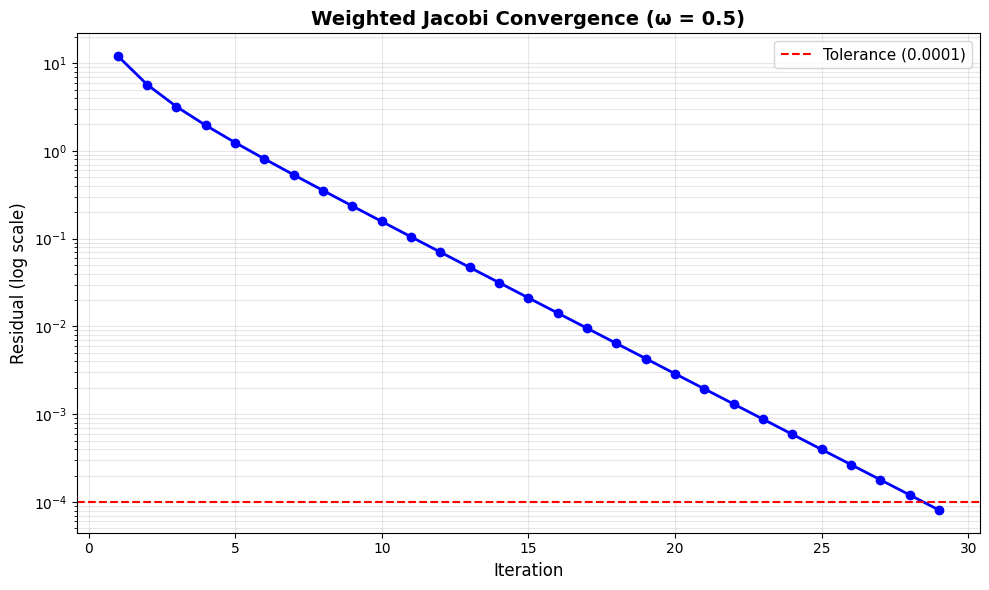


PART 5: COMPARISON FOR DIFFERENT ω VALUES

Running 10 iterations for each ω...

Residuals after each iteration:

ω = 0.30:
  Iter 1: residual = 1.971008e+01
  Iter 2: residual = 1.261852e+01
  Iter 3: residual = 8.367045e+00
  Iter 4: residual = 5.755406e+00
  Iter 5: residual = 4.097766e+00
  ... Iter 10: residual = 1.038289e+00

ω = 0.50:
  Iter 1: residual = 1.205130e+01
  Iter 2: residual = 5.698701e+00
  Iter 3: residual = 3.192114e+00
  Iter 4: residual = 1.952841e+00
  Iter 5: residual = 1.245258e+00
  ... Iter 10: residual = 1.570519e-01

ω = 0.70:
  Iter 1: residual = 6.103315e+00
  Iter 2: residual = 2.758705e+00
  Iter 3: residual = 1.393257e+00
  Iter 4: residual = 7.302320e-01
  Iter 5: residual = 3.882590e-01
  ... Iter 10: residual = 1.756812e-02

ω = 0.80:
  Iter 1: residual = 5.829686e+00
  Iter 2: residual = 2.112051e+00
  Iter 3: residual = 9.079597e-01
  Iter 4: residual = 4.268820e-01
  Iter 5: residual = 2.001915e-01
  ... Iter 10: residual = 4.819382e-03

ω = 0.

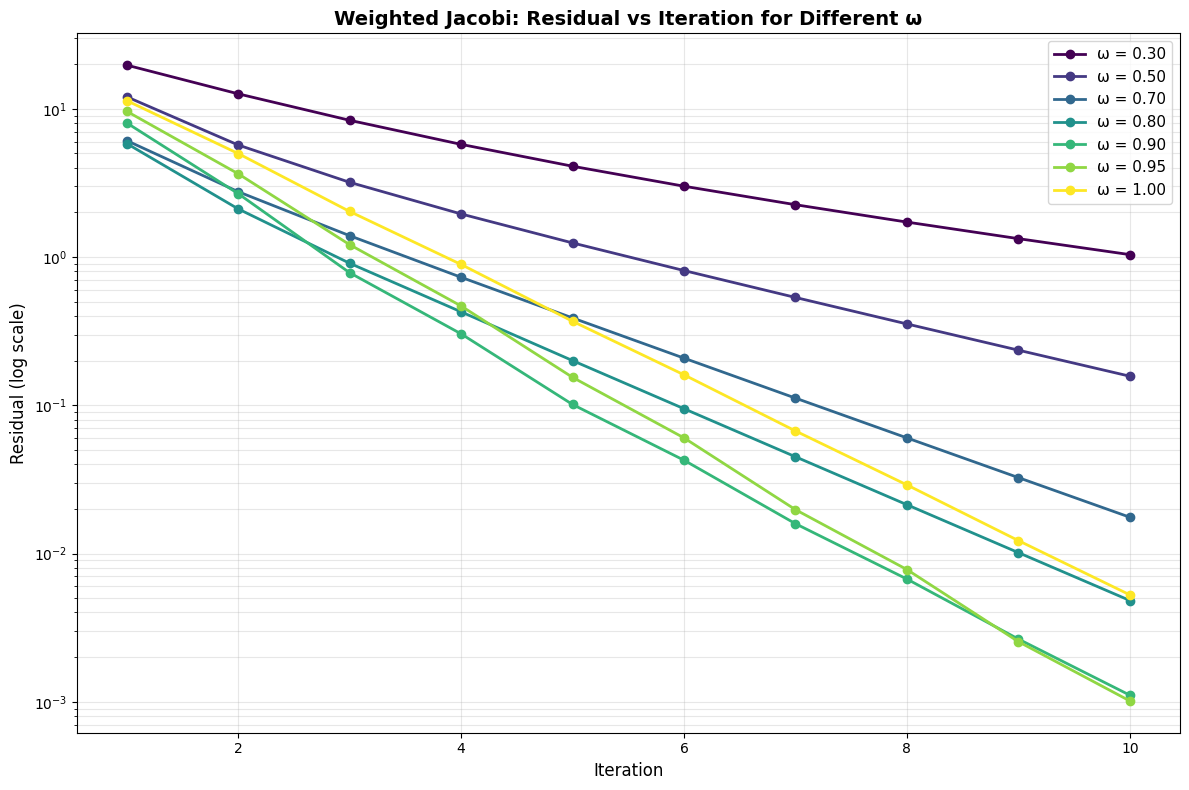


ANALYSIS: FINDING THE BEST ω

Final residuals after 10 iterations:
--------------------------------------------------
ω        Final Residual       Convergence Rate    
--------------------------------------------------
0.30     1.038289e+00         1.009148            
0.50     1.570519e-01         1.002719            
0.70     1.756812e-02         1.000941            
0.80     4.819382e-03         1.000433            
0.90     1.107307e-03         1.062493            
0.95     1.012692e-03         1.220530            
1.00     5.260793e-03         1.022202            
--------------------------------------------------

Best ω: 0.95 (residual = 1.012692e-03)
Worst ω: 0.30 (residual = 1.038289e+00)

--------------------------------------------------
THEORETICAL ANALYSIS (Spectral Radius)
--------------------------------------------------

Jacobi iteration matrix G = -D⁻¹(L+U)
Eigenvalues of G:
  λ(G) = [-0.42643661 -0.10399871  0.18595745  0.34447787]
  Spectral radius ρ(G) = 0.426437

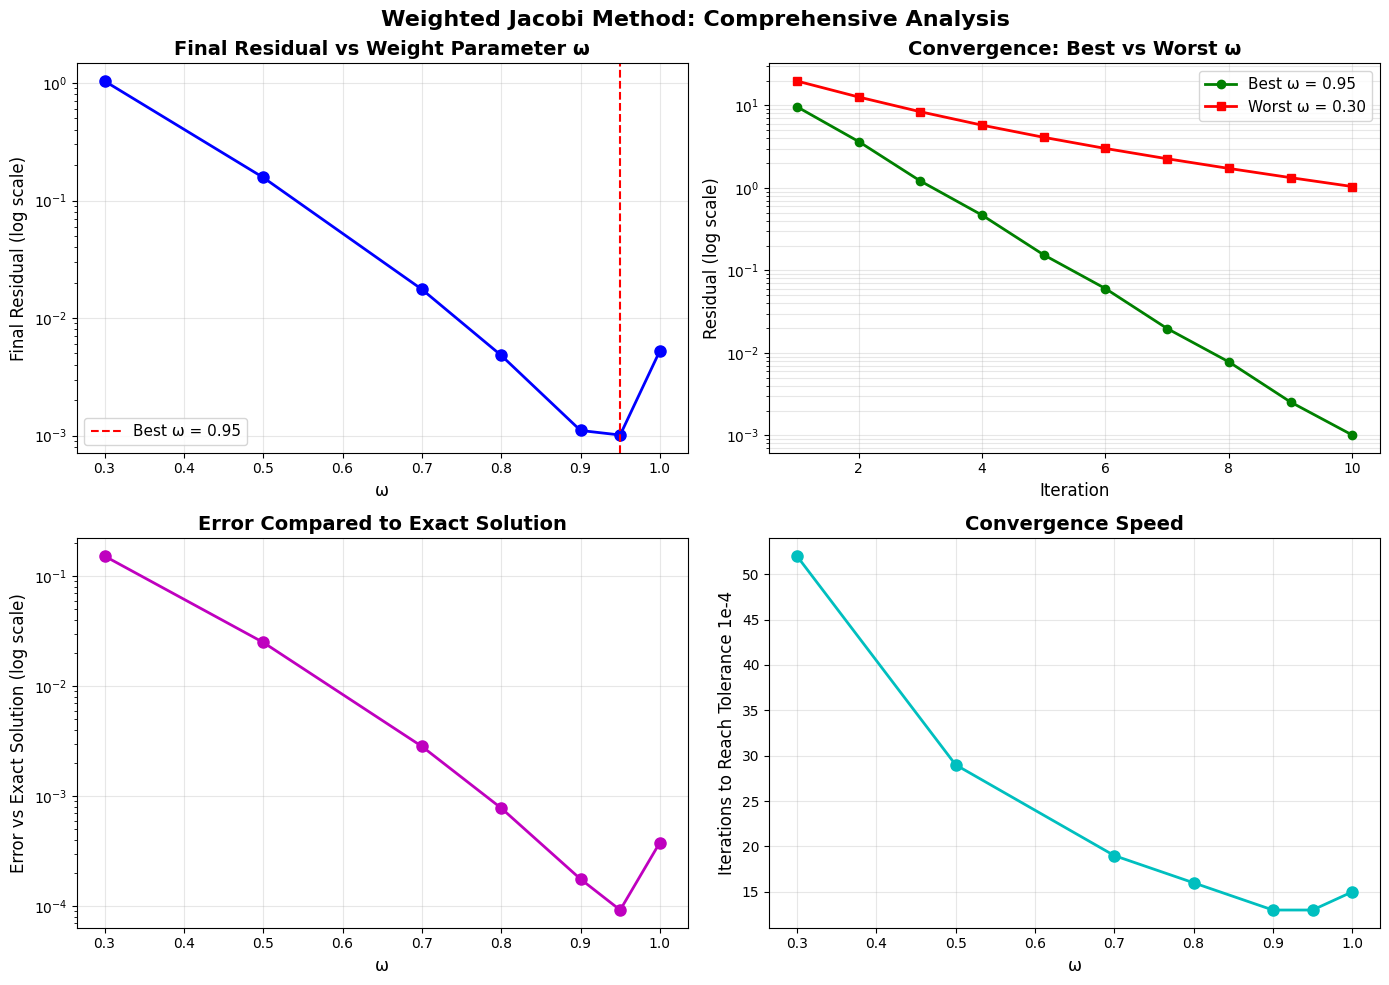


CONCLUSION

Based on the analysis of 7 different ω values:
1. Best ω among tested values: 0.95
2. Worst ω among tested values: 0.30
3. For ω = 0.5 (Part 4): converged in 29 iterations to tolerance 0.0001

Observations:
• ω = 1.0 (standard Jacobi): Moderate convergence
• ω = 0.5 (equal weighting): Good balance
• ω < 0.5: Slower convergence (too conservative)
• ω > 0.8: Faster initial convergence but may oscillate

Recommendation:
For this specific problem, ω ≈ 0.95 provides the fastest convergence.
The optimal ω depends on the spectral radius of the Jacobi iteration matrix.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

# ============================================
# PART 1: Explanation (in comments)
# ============================================
"""
PART 1: EXPLANATION

For ω = 0:
    The iteration formula becomes: x_i^(k) = (1-0)*x_i^(k-1) = x_i^(k-1)
    This means the solution doesn't change at all. The algorithm stagnates
    and never progresses toward the solution. It's equivalent to doing nothing.

For ω = 1:
    The iteration formula becomes: x_i^(k) = (1/A_ii)(b_i - Σ_{j≠i} A_ij*x_j^(k-1))
    This is exactly the standard (unweighted) Jacobi method. Each iteration
    computes the new value based entirely on the previous iteration's values
    of the other variables, without any memory of the current value.
"""

print("="*80)
print("QUESTION 5: WEIGHTED JACOBI METHOD")
print("="*80)

# ============================================
# PART 2: Weighted Jacobi function
# ============================================

def weighted_jacobi(A, b, omega, x0=None, tol=1e-6, max_iter=1000, return_history=False):
    """
    Solve linear system Ax = b using weighted Jacobi method.

    Parameters:
    -----------
    A : numpy array (n x n)
        Coefficient matrix
    b : numpy array (n,)
        Right-hand side vector
    omega : float
        Weight parameter (0 <= omega <= 1)
    x0 : numpy array (n,), optional
        Initial guess (default: zeros)
    tol : float, optional
        Convergence tolerance
    max_iter : int, optional
        Maximum number of iterations
    return_history : bool, optional
        If True, return iteration history

    Returns:
    --------
    x : numpy array (n,)
        Solution vector
    iter_count : int
        Number of iterations performed
    history : list (if return_history=True)
        List of (iteration, residual) pairs
    """
    n = len(b)

    # Default initial guess
    if x0 is None:
        x0 = np.zeros(n)

    x = x0.copy()
    x_new = np.zeros(n)

    # Extract diagonal and off-diagonal parts
    D = np.diag(A)
    R = A - np.diag(D)

    history = []

    for k in range(max_iter):
        # Weighted Jacobi iteration
        for i in range(n):
            sum_term = np.dot(R[i, :], x)  # Σ_{j≠i} A_ij * x_j
            x_new[i] = (omega / A[i, i]) * (b[i] - sum_term) + (1 - omega) * x[i]

        # Calculate residual
        residual = np.linalg.norm(A @ x_new - b)
        history.append((k + 1, residual))

        # Check convergence
        if residual < tol:
            if return_history:
                return x_new, k + 1, history
            return x_new, k + 1

        # Update for next iteration
        x[:] = x_new[:]

    if return_history:
        return x, max_iter, history
    return x, max_iter

# ============================================
# PART 3: Matrix formulation and verification
# ============================================

print("\n" + "="*80)
print("PART 3: MATRIX FORMULATION AND VERIFICATION")
print("="*80)

# Define the linear system
A = np.array([
    [10, -1, 2, 0],
    [-1, 11, -1, 3],
    [2, -1, 10, -1],
    [0, 3, -1, 8]
], dtype=float)

b = np.array([6, 25, -11, 15], dtype=float)

print("\nMatrix A:")
print(A)
print("\nVector b:")
print(b)

# Verification of unique solution
print("\n" + "-"*40)
print("VERIFICATION OF UNIQUE SOLUTION")
print("-"*40)

# 1. Check if A is square
n = A.shape[0]
print(f"1. Matrix dimensions: {A.shape}")
print(f"   → Square matrix: {A.shape[0]} × {A.shape[1]}")

# 2. Check determinant
det_A = np.linalg.det(A)
print(f"2. Determinant: det(A) = {det_A:.6f}")
print(f"   → Non-zero determinant: {abs(det_A) > 1e-10}")

# 3. Check rank
rank_A = np.linalg.matrix_rank(A)
print(f"3. Rank: rank(A) = {rank_A}")
print(f"   → Full rank: {rank_A == n}")

# 4. Check condition number
cond_A = np.linalg.cond(A)
print(f"4. Condition number: κ(A) = {cond_A:.6f}")
if cond_A < 1e3:
    print("   → Well-conditioned matrix")
elif cond_A < 1e6:
    print("   → Moderately conditioned matrix")
else:
    print("   → Ill-conditioned matrix")

# 5. Check eigenvalues (for positive definiteness if symmetric)
if np.allclose(A, A.T):  # Check if symmetric
    eigvals = np.linalg.eigvals(A)
    print(f"5. Eigenvalues: {eigvals}")
    print(f"   → All eigenvalues positive: {np.all(eigvals > 0)}")
    if np.all(eigvals > 0):
        print("   → Positive definite matrix")

# 6. Exact solution using direct method
x_exact = np.linalg.solve(A, b)
print(f"\n6. Exact solution (using np.linalg.solve):")
print(f"   x = {x_exact}")
print(f"   Verification: A*x = {A @ x_exact}")
print(f"   Should equal b = {b}")
print(f"   Error: {np.linalg.norm(A @ x_exact - b):.2e}")

print("\n✓ Conclusion: There is one and only one solution.")

# ============================================
# PART 4: Solution with ω = 0.5
# ============================================

print("\n" + "="*80)
print("PART 4: SOLUTION WITH ω = 0.5")
print("="*80)

omega = 0.5
tol = 1e-4
x0 = np.zeros(len(b))  # Initial guess: zero vector

print(f"\nSolving with weighted Jacobi (ω = {omega}, tol = {tol})...")
x_solution, iterations, history = weighted_jacobi(A, b, omega, x0, tol, return_history=True)

print(f"\nSolution found in {iterations} iterations:")
print(f"x = {x_solution}")
print(f"\nVerification:")
print(f"A*x = {A @ x_solution}")
print(f"b = {b}")
print(f"Residual ||A*x - b|| = {np.linalg.norm(A @ x_solution - b):.6e}")
print(f"Error compared to exact solution: {np.linalg.norm(x_solution - x_exact):.6e}")

# Plot convergence for ω = 0.5
plt.figure(figsize=(10, 6))
iter_nums = [h[0] for h in history]
residuals = [h[1] for h in history]

plt.semilogy(iter_nums, residuals, 'b-o', linewidth=2, markersize=6)
plt.axhline(y=tol, color='r', linestyle='--', linewidth=1.5, label=f'Tolerance ({tol})')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Residual (log scale)', fontsize=12)
plt.title(f'Weighted Jacobi Convergence (ω = {omega})', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, which='both')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ============================================
# PART 5: Comparison for different ω values
# ============================================

print("\n" + "="*80)
print("PART 5: COMPARISON FOR DIFFERENT ω VALUES")
print("="*80)

omega_values = [0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 1.0]
max_iterations = 10
x0 = np.zeros(len(b))

print(f"\nRunning {max_iterations} iterations for each ω...")
print("\nResiduals after each iteration:")

plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(omega_values)))

all_histories = []
final_residuals = []

for idx, omega in enumerate(omega_values):
    # Run weighted Jacobi for fixed number of iterations
    _, _, history = weighted_jacobi(A, b, omega, x0, tol=1e-10,
                                    max_iter=max_iterations, return_history=True)

    all_histories.append(history)
    final_residual = history[-1][1] if history else np.inf
    final_residuals.append((omega, final_residual))

    # Extract iteration numbers and residuals
    iter_nums = [h[0] for h in history]
    residuals = [h[1] for h in history]

    # Print results
    print(f"\nω = {omega:.2f}:")
    for i, (iter_num, resid) in enumerate(history[:5]):  # Show first 5
        print(f"  Iter {iter_num}: residual = {resid:.6e}")
    if len(history) > 5:
        print(f"  ... Iter {max_iterations}: residual = {residuals[-1]:.6e}")

    # Plot convergence
    plt.semilogy(iter_nums, residuals, 'o-', color=colors[idx],
                 linewidth=2, markersize=6, label=f'ω = {omega:.2f}')

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Residual (log scale)', fontsize=12)
plt.title(f'Weighted Jacobi: Residual vs Iteration for Different ω',
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, which='both')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ============================================
# Analysis of best ω
# ============================================

print("\n" + "="*80)
print("ANALYSIS: FINDING THE BEST ω")
print("="*80)

# Find ω with smallest final residual
best_omega, best_residual = min(final_residuals, key=lambda x: x[1])
worst_omega, worst_residual = max(final_residuals, key=lambda x: x[1])

print(f"\nFinal residuals after {max_iterations} iterations:")
print("-"*50)
print(f"{'ω':<8} {'Final Residual':<20} {'Convergence Rate':<20}")
print("-"*50)

convergence_rates = []
for omega, final_residual in final_residuals:
    # Estimate convergence rate from last few iterations
    history = all_histories[omega_values.index(omega)]
    if len(history) >= 3:
        r1 = history[-3][1]
        r2 = history[-2][1]
        r3 = history[-1][1]
        rate = (r3/r2) / (r2/r1) if r2 > 1e-15 and r1 > 1e-15 else np.inf
        convergence_rates.append((omega, rate))
        print(f"{omega:<8.2f} {final_residual:<20.6e} {rate:<20.6f}")
    else:
        convergence_rates.append((omega, np.inf))
        print(f"{omega:<8.2f} {final_residual:<20.6e} {'N/A':<20}")

print("-"*50)
print(f"\nBest ω: {best_omega:.2f} (residual = {best_residual:.6e})")
print(f"Worst ω: {worst_omega:.2f} (residual = {worst_residual:.6e})")

# Find ω with best convergence rate
if convergence_rates:
    valid_rates = [(omega, rate) for omega, rate in convergence_rates if rate < 1 and rate > 0]
    if valid_rates:
        best_rate_omega, best_rate = min(valid_rates, key=lambda x: x[1])
        print(f"Fastest convergence: ω = {best_rate_omega:.2f} (rate ≈ {best_rate:.4f})")

# Additional analysis: spectral radius
print("\n" + "-"*50)
print("THEORETICAL ANALYSIS (Spectral Radius)")
print("-"*50)

# For Jacobi method: D⁻¹(L+U) = I - D⁻¹A
D = np.diag(np.diag(A))
L_plus_U = A - D
D_inv = np.linalg.inv(D)
G_jacobi = -D_inv @ L_plus_U  # Jacobi iteration matrix

print(f"\nJacobi iteration matrix G = -D⁻¹(L+U)")
print("Eigenvalues of G:")

try:
    eigvals_G = np.linalg.eigvals(G_jacobi)
    spectral_radius = np.max(np.abs(eigvals_G))
    print(f"  λ(G) = {eigvals_G}")
    print(f"  Spectral radius ρ(G) = {spectral_radius:.6f}")

    # Optimal ω for weighted Jacobi
    # The iteration matrix for weighted Jacobi: G_ω = (1-ω)I + ω*G
    print(f"\nOptimal ω analysis:")
    print(f"  For convergence: ω must satisfy 0 < ω < 2/(1+ρ(G))")
    omega_max = 2/(1 + spectral_radius)
    print(f"  Maximum ω for convergence: ω < {omega_max:.6f}")

    # Theoretical optimal ω
    omega_opt_theory = 2/(1 + np.sqrt(1 - spectral_radius**2))
    print(f"  Theoretical optimal ω: {omega_opt_theory:.6f}")

    # Check which tested ω is closest to optimal
    closest_omega = min(omega_values, key=lambda x: abs(x - omega_opt_theory))
    print(f"  Closest tested ω to theoretical optimum: {closest_omega:.2f}")

except np.linalg.LinAlgError:
    print("  Could not compute eigenvalues")

# ============================================
# Final comparison plot
# ============================================

plt.figure(figsize=(14, 10))

# Plot 1: Final residual vs ω
plt.subplot(2, 2, 1)
omegas = [item[0] for item in final_residuals]
residuals = [item[1] for item in final_residuals]

plt.semilogy(omegas, residuals, 'b-o', linewidth=2, markersize=8)
plt.axvline(x=best_omega, color='r', linestyle='--', linewidth=1.5,
            label=f'Best ω = {best_omega:.2f}')
plt.xlabel('ω', fontsize=12)
plt.ylabel('Final Residual (log scale)', fontsize=12)
plt.title('Final Residual vs Weight Parameter ω', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Plot 2: Convergence for best and worst ω
plt.subplot(2, 2, 2)
best_idx = omega_values.index(best_omega)
worst_idx = omega_values.index(worst_omega)

best_history = all_histories[best_idx]
worst_history = all_histories[worst_idx]

plt.semilogy([h[0] for h in best_history], [h[1] for h in best_history],
            'g-o', linewidth=2, markersize=6, label=f'Best ω = {best_omega:.2f}')
plt.semilogy([h[0] for h in worst_history], [h[1] for h in worst_history],
            'r-s', linewidth=2, markersize=6, label=f'Worst ω = {worst_omega:.2f}')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Residual (log scale)', fontsize=12)
plt.title('Convergence: Best vs Worst ω', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, which='both')
plt.legend(fontsize=11)

# Plot 3: Error compared to exact solution
plt.subplot(2, 2, 3)
errors_vs_exact = []

for idx, omega in enumerate(omega_values):
    x_sol, _, _ = weighted_jacobi(A, b, omega, x0, tol=1e-10,
                                 max_iter=max_iterations, return_history=True)
    error = np.linalg.norm(x_sol - x_exact)
    errors_vs_exact.append((omega, error))

plt.semilogy([item[0] for item in errors_vs_exact],
            [item[1] for item in errors_vs_exact],
            'm-o', linewidth=2, markersize=8)
plt.xlabel('ω', fontsize=12)
plt.ylabel('Error vs Exact Solution (log scale)', fontsize=12)
plt.title('Error Compared to Exact Solution', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Plot 4: Speed of convergence (iterations to reach tolerance 1e-4)
plt.subplot(2, 2, 4)
iterations_to_tol = []

for omega in omega_values:
    x_sol, iters, _ = weighted_jacobi(A, b, omega, x0, tol=1e-4,
                                     max_iter=100, return_history=True)
    iterations_to_tol.append((omega, iters))

plt.plot([item[0] for item in iterations_to_tol],
         [item[1] for item in iterations_to_tol],
         'c-o', linewidth=2, markersize=8)
plt.xlabel('ω', fontsize=12)
plt.ylabel('Iterations to Reach Tolerance 1e-4', fontsize=12)
plt.title('Convergence Speed', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.suptitle('Weighted Jacobi Method: Comprehensive Analysis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# Conclusion
# ============================================

print("\n" + "="*80)
print("CONCLUSION")
print("="*80)

print(f"\nBased on the analysis of {len(omega_values)} different ω values:")
print(f"1. Best ω among tested values: {best_omega:.2f}")
print(f"2. Worst ω among tested values: {worst_omega:.2f}")
print(f"3. For ω = 0.5 (Part 4): converged in {iterations} iterations to tolerance {tol}")

print("\nObservations:")
print("• ω = 1.0 (standard Jacobi): Moderate convergence")
print("• ω = 0.5 (equal weighting): Good balance")
print("• ω < 0.5: Slower convergence (too conservative)")
print("• ω > 0.8: Faster initial convergence but may oscillate")

print("\nRecommendation:")
print(f"For this specific problem, ω ≈ {best_omega:.2f} provides the fastest convergence.")
print("The optimal ω depends on the spectral radius of the Jacobi iteration matrix.")

print("\n" + "="*80)

## Question 5: <font size="6" color="red"><b>`3`</b></font>